# Tech Pulse v2 — Sentiment & Stock Correlation

Rebuilt with continuous daily HN coverage (50k+ stories/year).

## What's new vs v1
| v1 | v2 |
|----|----|
| 18k stories, year-end only | 700k+ stories, every day |
| Single-day sentiment | Rolling 3/5/7-day windows |
| No momentum signal | Sentiment momentum (rising/falling) |
| No volume signal | Story volume surge z-score |
| T+1 and T+2 only | T+1 through T+7 correlation matrix |
| No event zoom | Key moment zoom charts |

## Pipeline
```
hn_data/hn_{YEAR}.csv  →  VADER scores  →  rolling signals
stocks/prices_{TICKER}.csv  →  abnormal returns
signals × returns  →  correlation matrix  →  charts
```

---
## 0. Install dependencies

In [1]:
# !pip install vaderSentiment pandas requests python-dotenv matplotlib seaborn scipy

---
## 1. Configuration

In [2]:
import os, io, re, requests, warnings
import pandas as pd
import numpy as np
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()

# GitHub
GITHUB_REPO   = 'annhmartin/dataviz-historical-stocks-AnnetteMartin'
GITHUB_TOKEN  = os.environ.get('GITHUB_TOKEN', None)
STOCKS_PREFIX = 'stocks'
HN_PREFIX     = 'hn_data'

# Date range to analyse
ANALYSIS_START = '2015-01-01'   # start here — earlier years have lower HN volume
ANALYSIS_END   = '2026-06-30'   # through today

# Signal thresholds
ZSCORE_THRESHOLD    = 1.5    # std devs above normal for 'abnormal' price move
MIN_SENT_DAYS       = 20     # min days of sentiment data to include a ticker
SENTIMENT_THRESHOLD = 0.05   # VADER compound: >0.05 positive, <-0.05 negative

# Rolling windows to test (days)
ROLLING_WINDOWS = [1, 3, 5, 7]

# Price horizons to test (trading days forward)
PRICE_HORIZONS = [1, 2, 3, 5, 7]

print('Configuration loaded')
print(f'  Repo            : {GITHUB_REPO}')
print(f'  Token           : {"set" if GITHUB_TOKEN else "NOT SET"}')
print(f'  Analysis window : {ANALYSIS_START} to {ANALYSIS_END}')
print(f'  Rolling windows : {ROLLING_WINDOWS} days')
print(f'  Price horizons  : {PRICE_HORIZONS} days')

Configuration loaded
  Repo            : annhmartin/dataviz-historical-stocks-AnnetteMartin
  Token           : set
  Analysis window : 2015-01-01 to 2026-06-30
  Rolling windows : [1, 3, 5, 7] days
  Price horizons  : [1, 2, 3, 5, 7] days


---
## 2. Company keyword map

Three-layer lookup: ticker symbol, company name, domain keywords.
Review and edit — add rows, remove rows, or tweak keywords as needed.

In [3]:
COMPANY_MAP = {
    'AAPL': {'names': ['apple'], 'keywords': ['iphone', 'ipad', 'macos', 'ios', 'app store', 'macbook', 'airpods', 'apple watch', 'swift', 'xcode', 'siri']},
    'MSFT': {'names': ['microsoft'], 'keywords': ['windows', 'azure', 'office 365', 'teams', 'copilot', 'github', 'xbox', 'bing', 'activision', 'openai', 'powershell', 'visual studio', 'typescript']},
    'GOOGL': {'names': ['google', 'alphabet', 'deepmind'], 'keywords': ['android', 'chrome', 'youtube', 'gmail', 'google cloud', 'gemini', 'bard', 'waymo', 'pixel', 'search engine', 'tpu']},
    'META': {'names': ['meta', 'facebook', 'instagram', 'whatsapp', 'oculus'], 'keywords': ['metaverse', 'llama', 'reels', 'threads', 'react native', 'pytorch', 'vr headset', 'quest']},
    'AMZN': {'names': ['amazon', 'aws'], 'keywords': ['prime', 'ec2', 's3', 'lambda', 'alexa', 'kindle', 'cloud computing', 'ecommerce', 'fulfillment', 'twitch']},
    'NVDA': {'names': ['nvidia'], 'keywords': ['gpu', 'cuda', 'geforce', 'ai chip', 'h100', 'a100', 'graphics card', 'deep learning hardware', 'tensorrt', 'data center gpu', 'blackwell']},
    'TSM':  {'names': ['tsmc', 'taiwan semiconductor'], 'keywords': ['chip fabrication', 'semiconductor foundry', '3nm', '5nm', '2nm', 'advanced packaging', 'chipmaker']},
    'INTC': {'names': ['intel'], 'keywords': ['x86', 'core processor', 'xeon', 'optane', 'arc gpu', 'intel foundry', 'gaudi']},
    'AMD':  {'names': ['amd', 'advanced micro devices'], 'keywords': ['ryzen', 'epyc', 'radeon', 'instinct mi', 'zen architecture']},
    'QCOM': {'names': ['qualcomm'], 'keywords': ['snapdragon', '5g modem', 'arm chip', 'mobile processor']},
    'CRM':  {'names': ['salesforce'], 'keywords': ['crm software', 'sales cloud', 'einstein ai', 'slack', 'tableau']},
    'NOW':  {'names': ['servicenow'], 'keywords': ['itsm', 'it service management', 'workflow automation']},
    'SNOW': {'names': ['snowflake'], 'keywords': ['data warehouse', 'data cloud', 'snowpark']},
    'DDOG': {'names': ['datadog'], 'keywords': ['observability', 'apm', 'log management', 'monitoring platform']},
    'MDB':  {'names': ['mongodb'], 'keywords': ['nosql', 'document database', 'atlas database']},
    'PLTR': {'names': ['palantir'], 'keywords': ['gotham', 'foundry platform', 'aip platform', 'defense ai', 'government analytics']},
    'CRWD': {'names': ['crowdstrike'], 'keywords': ['endpoint security', 'falcon platform', 'xdr security', 'threat intelligence']},
    'PANW': {'names': ['palo alto networks'], 'keywords': ['firewall', 'sase', 'zero trust network', 'prisma cloud']},
    'OKTA': {'names': ['okta'], 'keywords': ['identity management', 'sso', 'single sign-on', 'iam platform']},
    'PYPL': {'names': ['paypal', 'venmo'], 'keywords': ['digital wallet', 'online payment', 'buy now pay later']},
    'COIN': {'names': ['coinbase'], 'keywords': ['crypto exchange', 'cryptocurrency trading', 'defi', 'bitcoin', 'ethereum', 'blockchain']},
    'TSLA': {'names': ['tesla'], 'keywords': ['electric vehicle', 'autopilot', 'full self driving', 'supercharger', 'gigafactory', 'powerwall', 'elon musk']},
    'NFLX': {'names': ['netflix'], 'keywords': ['streaming service', 'content moderation', 'ad-supported tier']},
    'SPOT': {'names': ['spotify'], 'keywords': ['music streaming', 'podcast platform', 'audio streaming']},
    'INCY': {'names': ['incyte'], 'keywords': ['jak inhibitor', 'ruxolitinib', 'oncology drug', 'hematology', 'jakafi']},
    'KGC':  {'names': ['kinross gold'], 'keywords': ['gold mining', 'gold producer', 'precious metals mining']},
    'NVO':  {'names': ['novo nordisk'], 'keywords': ['ozempic', 'wegovy', 'glp-1', 'semaglutide', 'diabetes drug', 'obesity drug']},
    'PM':   {'names': ['philip morris'], 'keywords': ['iqos', 'heated tobacco', 'zyn', 'nicotine pouch']},
    'WPM':  {'names': ['wheaton precious metals'], 'keywords': ['silver streaming', 'gold streaming', 'precious metals royalty']},
}

print(f'Company map: {len(COMPANY_MAP)} tickers')
print(f'{"Ticker":<8} {"Names":<35} Keywords')
print('-' * 85)
for ticker, info in COMPANY_MAP.items():
    names = ', '.join(info['names'])
    kws   = ', '.join(info['keywords'][:4]) + (' ...' if len(info['keywords']) > 4 else '')
    print(f'  {ticker:<8} {names:<35} {kws}')

Company map: 29 tickers
Ticker   Names                               Keywords
-------------------------------------------------------------------------------------
  AAPL     apple                               iphone, ipad, macos, ios ...
  MSFT     microsoft                           windows, azure, office 365, teams ...
  GOOGL    google, alphabet, deepmind          android, chrome, youtube, gmail ...
  META     meta, facebook, instagram, whatsapp, oculus metaverse, llama, reels, threads ...
  AMZN     amazon, aws                         prime, ec2, s3, lambda ...
  NVDA     nvidia                              gpu, cuda, geforce, ai chip ...
  TSM      tsmc, taiwan semiconductor          chip fabrication, semiconductor foundry, 3nm, 5nm ...
  INTC     intel                               x86, core processor, xeon, optane ...
  AMD      amd, advanced micro devices         ryzen, epyc, radeon, instinct mi ...
  QCOM     qualcomm                            snapdragon, 5g modem, arm chip

---
## 3. GitHub loader

In [4]:
def load_csv_from_github(repo, path, token=None):
    raw_url = f'https://raw.githubusercontent.com/{repo}/main/{path}'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(raw_url, headers=headers, timeout=60)
    if resp.status_code == 404:
        raise FileNotFoundError(f'Not found: {path}')
    resp.raise_for_status()
    content = resp.text.strip()
    if not content:
        return pd.DataFrame()
    return pd.read_csv(io.StringIO(content), low_memory=False)

print('GitHub loader ready')

GitHub loader ready


---
## 4. Load HN data & run VADER sentiment

Loads all year files from `hn_data/`, scores titles with VADER, and filters to the analysis window.

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

print('Loading HN data from GitHub ...')
frames = []
start_year = int(ANALYSIS_START[:4])
end_year   = int(ANALYSIS_END[:4])

for year in range(start_year, end_year + 1):
    try:
        df_y = load_csv_from_github(GITHUB_REPO, f'{HN_PREFIX}/hn_{year}.csv', GITHUB_TOKEN)
        frames.append(df_y)
        print(f'  {year}: {len(df_y):,} stories')
    except FileNotFoundError:
        print(f'  {year}: not found - skipping')

df_hn = (
    pd.concat(frames, ignore_index=True)
    .drop_duplicates(subset='id')
    .reset_index(drop=True)
)
df_hn['date'] = pd.to_datetime(df_hn['date'], errors='coerce')
df_hn = df_hn[
    (df_hn['date'] >= ANALYSIS_START) &
    (df_hn['date'] <= ANALYSIS_END)
].reset_index(drop=True)

print(f'\nTotal after filtering: {len(df_hn):,} stories')
print(f'Date range: {df_hn["date"].min().date()} to {df_hn["date"].max().date()}')
print(f'Unique days: {df_hn["date"].nunique():,}')

# Score titles with VADER
print('\nScoring sentiment ...')
df_hn['sentiment'] = df_hn['title'].fillna('').apply(
    lambda t: analyzer.polarity_scores(str(t))['compound']
)
df_hn['sentiment_label'] = df_hn['sentiment'].apply(
    lambda s: 'positive' if s >= SENTIMENT_THRESHOLD
              else ('negative' if s <= -SENTIMENT_THRESHOLD else 'neutral')
)
print(f'  Positive: {(df_hn["sentiment_label"]=="positive").sum():,}')
print(f'  Neutral : {(df_hn["sentiment_label"]=="neutral").sum():,}')
print(f'  Negative: {(df_hn["sentiment_label"]=="negative").sum():,}')
df_hn[['title', 'date', 'sentiment', 'sentiment_label']].head(5)

Loading HN data from GitHub ...
  2015: 56,804 stories
  2016: 57,655 stories
  2017: 56,468 stories
  2018: 56,933 stories
  2019: 56,837 stories
  2020: 58,097 stories
  2021: 58,084 stories
  2022: 58,346 stories
  2023: 58,304 stories
  2024: 58,389 stories
  2025: 58,512 stories
  2026: 32,057 stories

Total after filtering: 662,599 stories
Date range: 2015-01-05 to 2026-06-29
Unique days: 2,174

Scoring sentiment ...
  Positive: 140,949
  Neutral : 391,276
  Negative: 130,374


,title,date,sentiment,sentiment_label
0,Rocketbin – Flask Pastebin clone,2015-01-05,0.0000,neutral
1,Weekend Project – I created a strong password ...,2015-01-05,0.6486,positive
2,Few minorities in non-tech jobs in Silicon Valley,2015-01-05,0.0000,neutral
3,Battlecode 2015 – AI Programming Competition,2015-01-05,0.0000,neutral
4,On Alcohol and Tech Culture,2015-01-05,0.0000,neutral


---
## 5. Match stories to companies

In [6]:
def find_mentioned_tickers(text):
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    words = set(text_lower.split())
    found = set()
    for ticker, info in COMPANY_MAP.items():
        if ticker.lower() in words:
            found.add(ticker)
            continue
        if any(name in text_lower for name in info['names']):
            found.add(ticker)
            continue
        if any(kw in text_lower for kw in info['keywords']):
            found.add(ticker)
    return list(found)

print('Matching stories to companies ...')
df_hn['tickers'] = df_hn['title'].apply(find_mentioned_tickers)
matched = df_hn[df_hn['tickers'].map(len) > 0]
print(f'  {len(matched):,} stories matched ({len(matched)/len(df_hn)*100:.1f}%)')
print(f'  {len(df_hn)-len(matched):,} stories had no company match')

df_matches = (
    df_hn[['id', 'date', 'title', 'sentiment', 'sentiment_label', 'tickers', 'points']]
    .explode('tickers')
    .rename(columns={'tickers': 'ticker'})
    .dropna(subset=['ticker'])
    .reset_index(drop=True)
)

coverage = df_matches.groupby('ticker')['id'].count().sort_values(ascending=False).rename('story_count')
print(f'\nTop 20 most-mentioned companies:')
print(coverage.head(20).to_string())

Matching stories to companies ...
  121,505 stories matched (18.3%)
  541,094 stories had no company match

Top 20 most-mentioned companies:
ticker
GOOGL    24230
MSFT     18022
AAPL     17755
META     16035
AMZN     13150
COIN      7685
NOW       7575
TSLA      6764
INTC      5644
OKTA      4128
NVDA      3475
AMD       1673
CRM       1584
NFLX      1382
SPOT      1179
MDB        501
TSM        479
PYPL       421
QCOM       338
DDOG       320


---
## 6. Build daily sentiment signals

Aggregates to one row per ticker per day, then computes:
- **Rolling windows** (3, 5, 7 day): smoothed sentiment averages
- **Sentiment momentum**: is buzz rising or falling vs prior week?
- **Volume surge**: is story count unusually high vs recent average?

In [7]:
df_matches['weighted_sent'] = df_matches['sentiment'] * (df_matches['points'].fillna(1) + 1)

daily_raw = (
    df_matches.groupby(['ticker', 'date'])
    .agg(
        story_count   = ('id',           'count'),
        avg_sentiment = ('sentiment',     'mean'),
        weighted_sent = ('weighted_sent', 'sum'),
        total_points  = ('points',        'sum'),
        pos_stories   = ('sentiment_label', lambda x: (x=='positive').sum()),
        neg_stories   = ('sentiment_label', lambda x: (x=='negative').sum()),
    )
    .reset_index()
)
daily_raw['norm_sentiment'] = (
    daily_raw['weighted_sent'] /
    (daily_raw['total_points'] + daily_raw['story_count'])
)
daily_raw['date'] = pd.to_datetime(daily_raw['date'])

# Build full date range per ticker so rolling windows work correctly
all_dates  = pd.date_range(ANALYSIS_START, ANALYSIS_END, freq='D')
all_tickers = daily_raw['ticker'].unique()
idx = pd.MultiIndex.from_product([all_tickers, all_dates], names=['ticker', 'date'])
daily = (
    daily_raw.set_index(['ticker', 'date'])
    .reindex(idx, fill_value=0)
    .reset_index()
)
# Fix fill: story_count=0 is correct, but sentiment should be NaN on empty days
daily.loc[daily['story_count'] == 0, ['avg_sentiment', 'norm_sentiment', 'weighted_sent']] = np.nan

# Rolling signals per ticker
print('Computing rolling signals ...')
signal_frames = []
for ticker in all_tickers:
    t = daily[daily['ticker'] == ticker].copy().sort_values('date')

    # Rolling sentiment windows
    for w in ROLLING_WINDOWS:
        t[f'sent_roll_{w}d'] = t['norm_sentiment'].rolling(w, min_periods=1).mean()

    # Sentiment momentum: today's 3d rolling vs 7 days ago 3d rolling
    t['sent_momentum'] = t['sent_roll_3d'] - t['sent_roll_3d'].shift(7)

    # Volume surge: z-score of story count vs 30-day rolling
    roll_mean = t['story_count'].rolling(30, min_periods=5).mean()
    roll_std  = t['story_count'].rolling(30, min_periods=5).std()
    t['volume_surge'] = (t['story_count'] - roll_mean) / (roll_std + 0.01)

    # Sentiment direction label
    t['sent_dir'] = t['norm_sentiment'].apply(
        lambda s: 'positive' if (isinstance(s, float) and not np.isnan(s) and s >= SENTIMENT_THRESHOLD)
                  else ('negative' if (isinstance(s, float) and not np.isnan(s) and s <= -SENTIMENT_THRESHOLD)
                  else 'neutral')
    )
    signal_frames.append(t)

daily_signals = pd.concat(signal_frames, ignore_index=True)
print(f'Daily signals: {len(daily_signals):,} ticker-days')
print(f'Tickers with data: {daily_signals["ticker"].nunique()}')
daily_signals.head()

Computing rolling signals ...
Daily signals: 121,771 ticker-days
Tickers with data: 29


,ticker,date,story_count,avg_sentiment,weighted_sent,total_points,pos_stories,neg_stories,norm_sentiment,sent_roll_1d,sent_roll_3d,sent_roll_5d,sent_roll_7d,sent_momentum,volume_surge,sent_dir
0,AAPL,2015-01-01,0,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
1,AAPL,2015-01-02,0,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
2,AAPL,2015-01-03,0,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
3,AAPL,2015-01-04,0,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
4,AAPL,2015-01-05,9,0.057889,-134.6247,630,2,1,-0.21068,-0.21068,-0.21068,-0.21068,-0.21068,NaN,1.784421,negative


---
## 7. Load stock prices & compute abnormal returns

In [8]:
tickers_to_load = [
    t for t in all_tickers
    if daily_signals[daily_signals['ticker']==t]['story_count'].sum() >= MIN_SENT_DAYS
]
print(f'Loading prices for {len(tickers_to_load)} tickers ...')

price_frames = []
for ticker in tickers_to_load:
    try:
        df_p = load_csv_from_github(GITHUB_REPO, f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
        if df_p.empty or 'Close' not in df_p.columns:
            continue
        df_p['Date']   = pd.to_datetime(df_p['Date'])
        df_p['ticker'] = ticker
        df_p = df_p.sort_values('Date').reset_index(drop=True)
        df_p['daily_return'] = df_p['Close'].pct_change(fill_method=None)
        df_p['roll_mean']    = df_p['daily_return'].rolling(60, min_periods=20).mean()
        df_p['roll_std']     = df_p['daily_return'].rolling(60, min_periods=20).std()
        df_p['zscore']       = (df_p['daily_return'] - df_p['roll_mean']) / df_p['roll_std']
        df_p['is_abnormal']  = df_p['zscore'].abs() >= ZSCORE_THRESHOLD
        price_frames.append(df_p[['Date','ticker','Close','daily_return','roll_std','zscore','is_abnormal']])
        print(f'  {ticker}: {len(df_p):,} rows', end='  ')
    except FileNotFoundError:
        print(f'  {ticker}: not found', end='  ')

print(f'\n\nLoaded {len(price_frames)} tickers')
df_prices = pd.concat(price_frames, ignore_index=True)

Loading prices for 26 tickers ...
  AAPL: 4,145 rows    AMD: 4,145 rows    AMZN: 4,145 rows    COIN: 1,307 rows    CRM: 4,145 rows    CRWD: 1,770 rows    DDOG: 1,701 rows    GOOGL: 4,145 rows    INTC: 4,145 rows    MDB: 2,182 rows    META: 3,546 rows    MSFT: 4,145 rows    NFLX: 4,145 rows    NOW: 3,517 rows    NVDA: 4,145 rows    NVO: 4,145 rows    OKTA: 2,317 rows    PANW: 3,503 rows    PLTR: 1,441 rows    PM: 4,145 rows    PYPL: 2,761 rows    QCOM: 4,145 rows    SNOW: not found    SPOT: not found    TSLA: 4,023 rows    TSM: 4,145 rows  

Loaded 24 tickers


---
## 8. Full correlation matrix

Tests every combination of:
- **Signal**: single-day, 3d, 5d, 7d rolling sentiment + momentum + volume surge
- **Horizon**: T+1 through T+7 price returns

Finds which signal × horizon pair has the strongest predictive power per ticker.

In [9]:
from scipy import stats

signal_cols = (
    ['norm_sentiment'] +
    [f'sent_roll_{w}d' for w in ROLLING_WINDOWS if w > 1] +
    ['sent_momentum', 'volume_surge']
)

all_results = []

for ticker in tickers_to_load:
    sig   = daily_signals[daily_signals['ticker'] == ticker].copy()
    price = df_prices[df_prices['ticker'] == ticker].copy()
    if sig.empty or price.empty:
        continue

    price = price.set_index('Date').sort_index()
    sig   = sig.set_index('date').sort_index()

    # Build forward returns for each horizon
    fwd_returns = {}
    for h in PRICE_HORIZONS:
        fwd_returns[h] = price['daily_return'].shift(-h)

    for signal_col in signal_cols:
        for horizon in PRICE_HORIZONS:
            # Align signal with forward price
            merged = pd.DataFrame({
                'signal': sig[signal_col],
                'fwd_ret': price['daily_return']
            }).dropna()

            # Match signal dates to forward return dates
            rows = []
            for date, sval in sig[signal_col].items():
                if pd.isna(sval):
                    continue
                future = price.index[price.index > date][:horizon]
                if len(future) < horizon:
                    continue
                ret = price.loc[future[-1], 'daily_return']
                if not pd.isna(ret):
                    rows.append({'signal': sval, 'ret': ret})

            if len(rows) < MIN_SENT_DAYS:
                continue

            df_pair = pd.DataFrame(rows)
            r, p = stats.pearsonr(df_pair['signal'], df_pair['ret'])

            all_results.append({
                'ticker'     : ticker,
                'signal'     : signal_col,
                'horizon'    : horizon,
                'corr'       : round(r, 4),
                'pval'       : round(p, 4),
                'n'          : len(df_pair),
                'significant': p < 0.05,
            })

df_corr = pd.DataFrame(all_results)
print(f'Correlation matrix: {len(df_corr):,} signal x horizon x ticker combinations')

# Best result per ticker — fixed index handling
best_per_ticker = (
    df_corr.assign(abs_corr=df_corr['corr'].abs())
    .sort_values('abs_corr', ascending=False)
    .drop_duplicates(subset='ticker')
    .drop(columns='abs_corr')
    .sort_values('corr', key=abs, ascending=False)
    .reset_index(drop=True)
)
print('\nBest signal per ticker (by absolute correlation):')
print(best_per_ticker[['ticker','signal','horizon','corr','pval','n','significant']].to_string(index=False))

Correlation matrix: 720 signal x horizon x ticker combinations

Best signal per ticker (by absolute correlation):
ticker         signal  horizon    corr   pval    n  significant
   NVO  sent_momentum        3 -0.2792 0.0029  112         True
  PANW  sent_momentum        3  0.2384 0.0110  113         True
  PLTR  sent_momentum        1  0.2265 0.0154  114         True
  CRWD norm_sentiment        5  0.2046 0.0968   67        False
    PM norm_sentiment        2  0.1627 0.0398  160         True
  COIN   sent_roll_7d        3  0.1124 0.0000 4179         True
  QCOM  sent_momentum        1 -0.1012 0.1945  166        False
   MDB  sent_momentum        2 -0.0965 0.0528  403        False
  PYPL  sent_momentum        7 -0.0939 0.1281  264        False
   TSM  sent_momentum        3  0.0932 0.0867  339        False
  DDOG norm_sentiment        5 -0.0725 0.2281  278        False
   CRM norm_sentiment        1 -0.0720 0.0254  964         True
 GOOGL   sent_roll_5d        1  0.0705 0.0000 4144    

---
## 9. Signal x Horizon heatmap

Shows average correlation across all tickers for each signal × horizon combination.
Helps identify which window and horizon are most predictive overall.

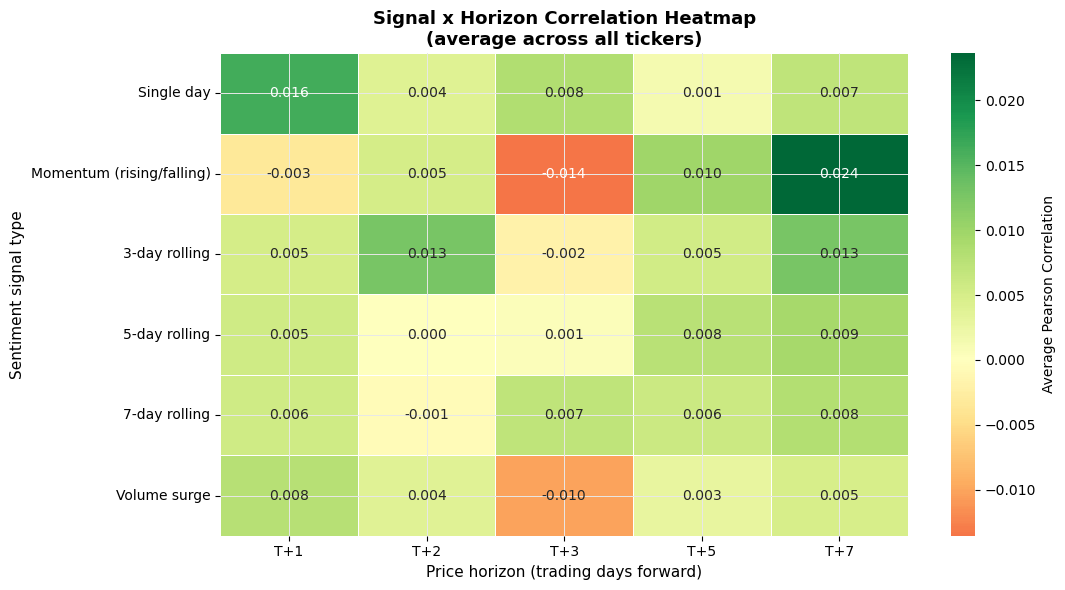

Green = positive correlation (positive buzz predicted price gains)
Red   = negative correlation
The darkest green cell = best overall signal x horizon combination


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.grid': True,
    'grid.color': '#e8e8e8', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
})

pivot = (
    df_corr.groupby(['signal', 'horizon'])['corr']
    .mean()
    .reset_index()
    .pivot(index='signal', columns='horizon', values='corr')
)

signal_labels = {
    'norm_sentiment'  : 'Single day',
    'sent_roll_3d'    : '3-day rolling',
    'sent_roll_5d'    : '5-day rolling',
    'sent_roll_7d'    : '7-day rolling',
    'sent_momentum'   : 'Momentum (rising/falling)',
    'volume_surge'    : 'Volume surge',
}
pivot.index = [signal_labels.get(i, i) for i in pivot.index]
pivot.columns = [f'T+{c}' for c in pivot.columns]

fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Average Pearson Correlation'},
)
ax.set_title('Signal x Horizon Correlation Heatmap\n(average across all tickers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Price horizon (trading days forward)', fontsize=11)
ax.set_ylabel('Sentiment signal type', fontsize=11)
plt.tight_layout()
plt.show()
print('Green = positive correlation (positive buzz predicted price gains)')
print('Red   = negative correlation')
print('The darkest green cell = best overall signal x horizon combination')

---
## 10. Top correlating tickers

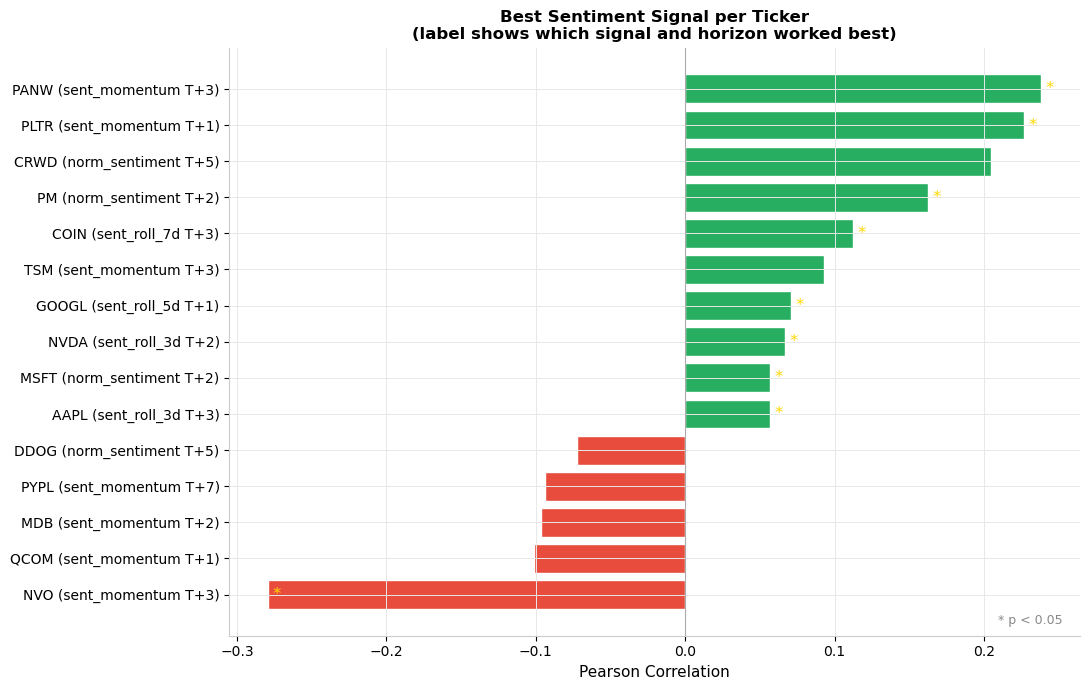

In [11]:
# Use the best signal found overall
if len(df_corr) > 0:
    best_combo = best_per_ticker.copy()  # already computed correctly in Section 8
    top10 = best_combo.nlargest(10, 'corr', keep='all')
    bot5  = best_combo.nsmallest(5,  'corr', keep='all')
    plot_df = pd.concat([top10, bot5]).drop_duplicates('ticker').sort_values('corr')

    fig, ax = plt.subplots(figsize=(11, 7), facecolor='white')
    colors = ['#e74c3c' if v < 0 else '#27ae60' for v in plot_df['corr']]
    bars = ax.barh(plot_df['ticker'] + ' (' + plot_df['signal'] + ' T+' + plot_df['horizon'].astype(str) + ')',
                   plot_df['corr'], color=colors, edgecolor='white')
    ax.axvline(0, color='#aaaaaa', linewidth=0.8)
    ax.set_xlabel('Pearson Correlation', fontsize=11)
    ax.set_title('Best Sentiment Signal per Ticker\n(label shows which signal and horizon worked best)',
                 fontsize=12, fontweight='bold')
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        if row['significant']:
            ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                    '*', va='center', fontsize=12, color='gold')
    ax.text(0.98, 0.02, '* p < 0.05', transform=ax.transAxes,
            ha='right', fontsize=9, color='#888888')
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.show()

---
## 11. Key Moment Zoom Charts

Automatically finds dates where:
1. Sentiment was strongly positive OR negative (top/bottom 10%)
2. The stock moved significantly in the predicted direction within 5 days

Then plots a 30-day window around each event showing what happened.

Finding key moments for top 5 tickers ...

Novo Nordisk (NVO) - 3 key moments found


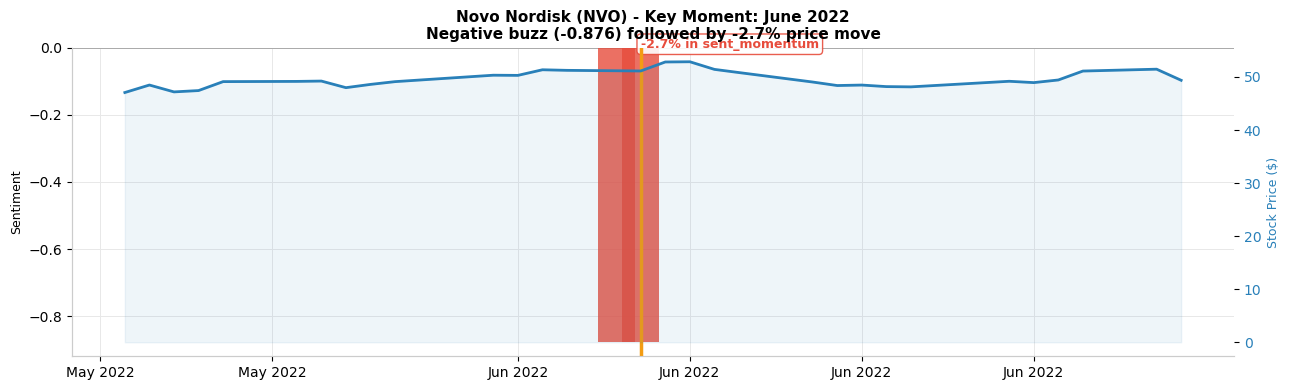

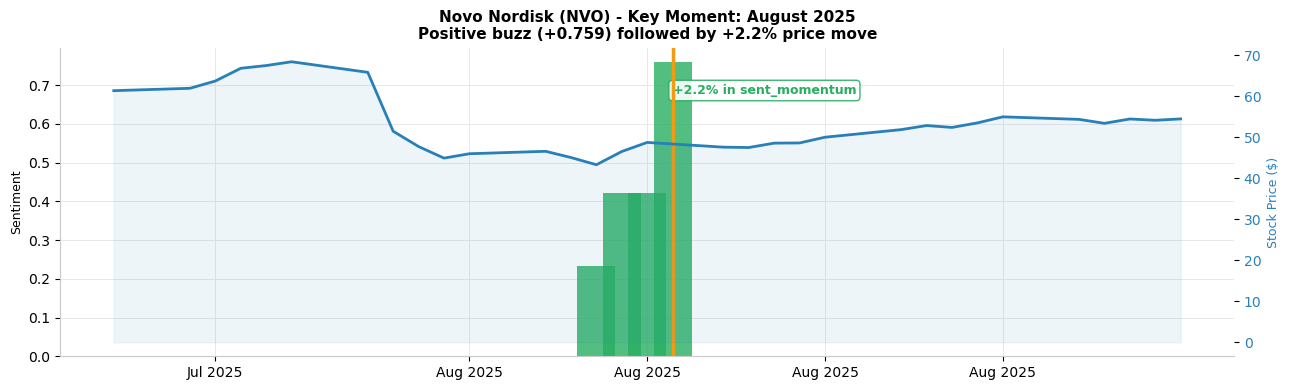

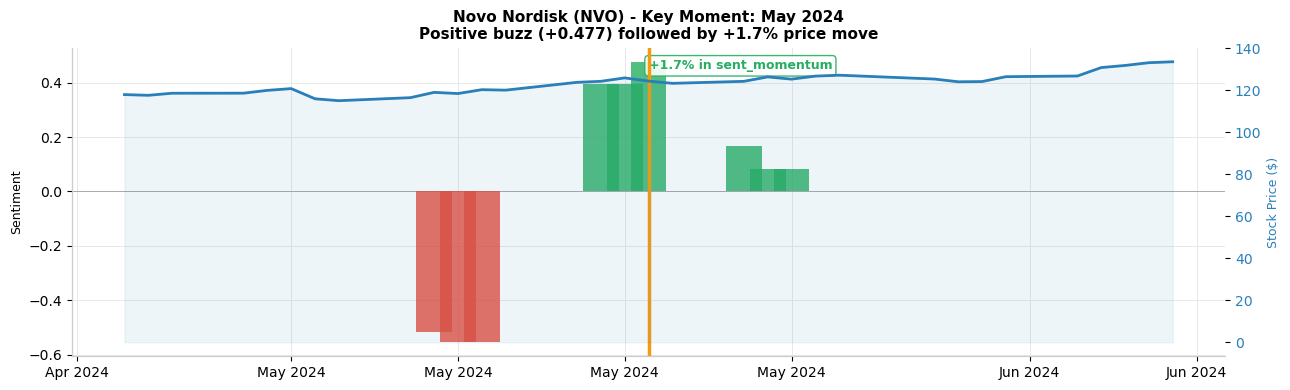


Palo Alto Networks (PANW) - 3 key moments found


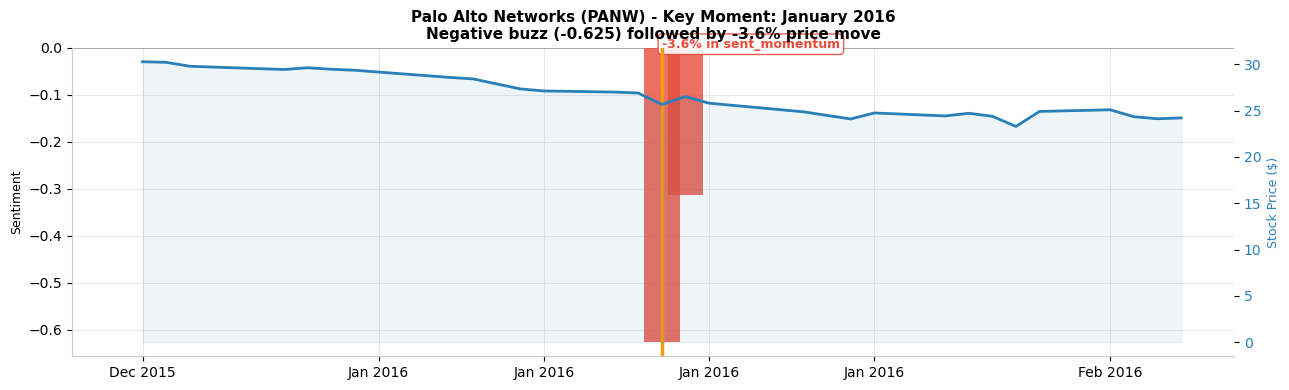

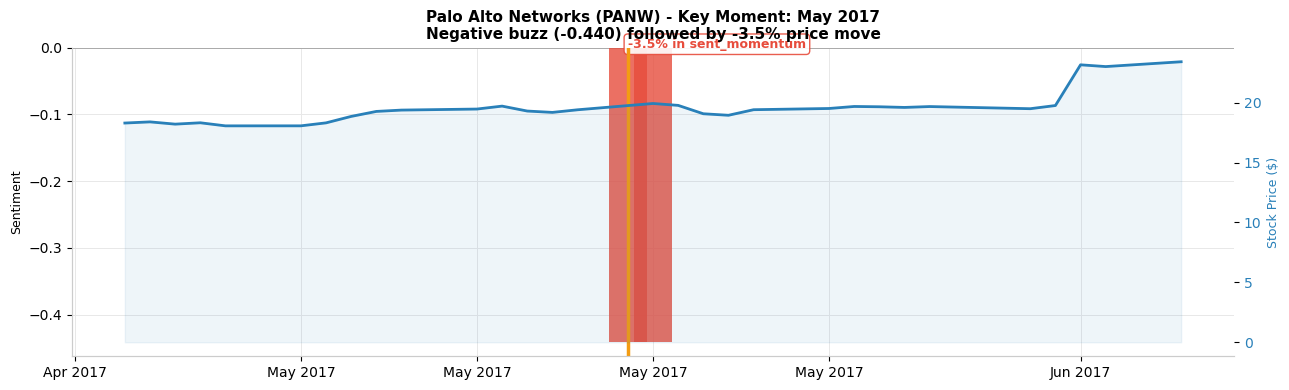

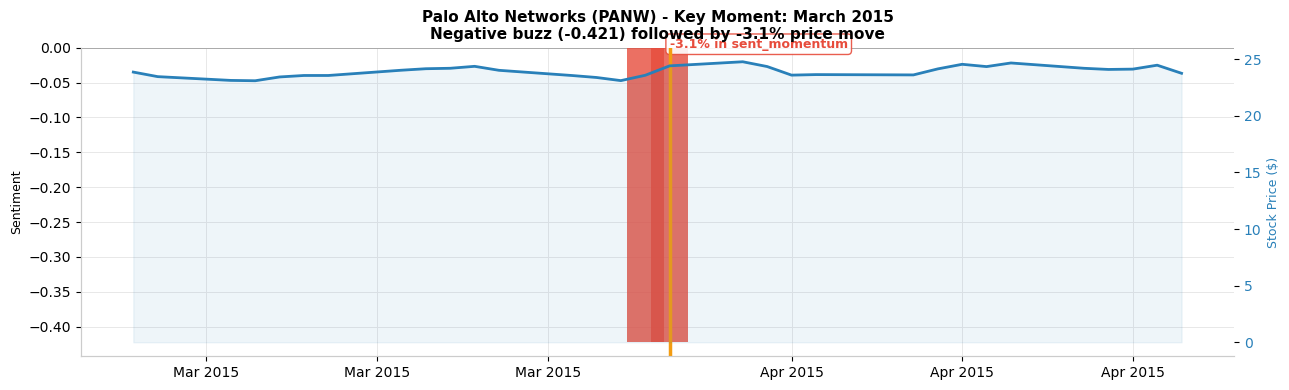


Palantir (PLTR) - 3 key moments found


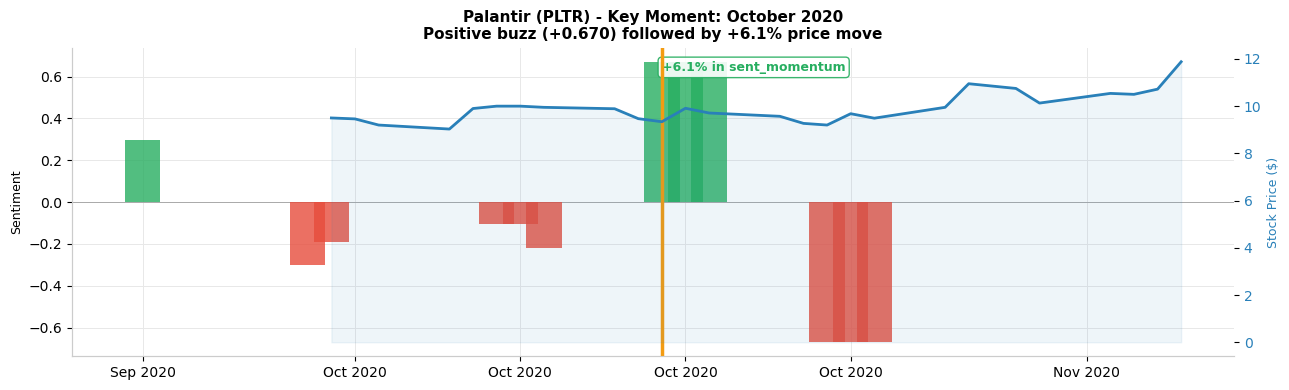

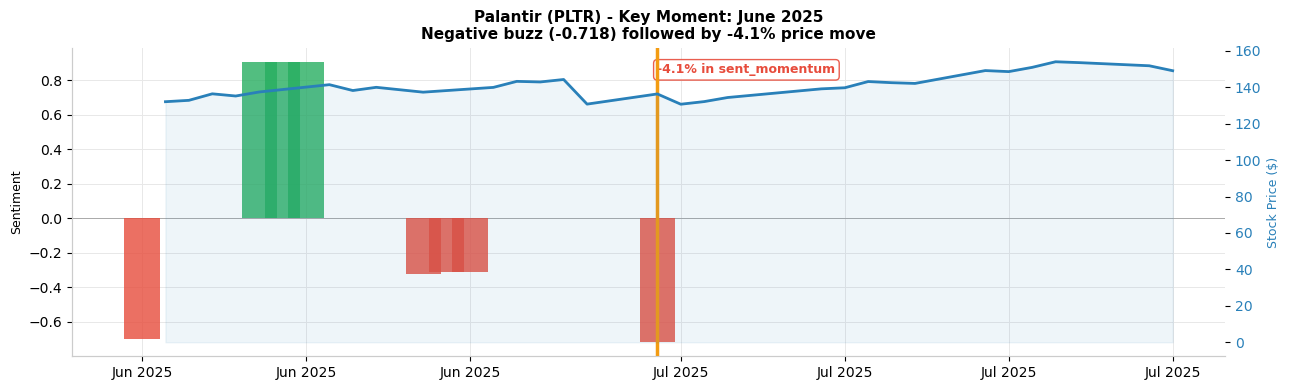

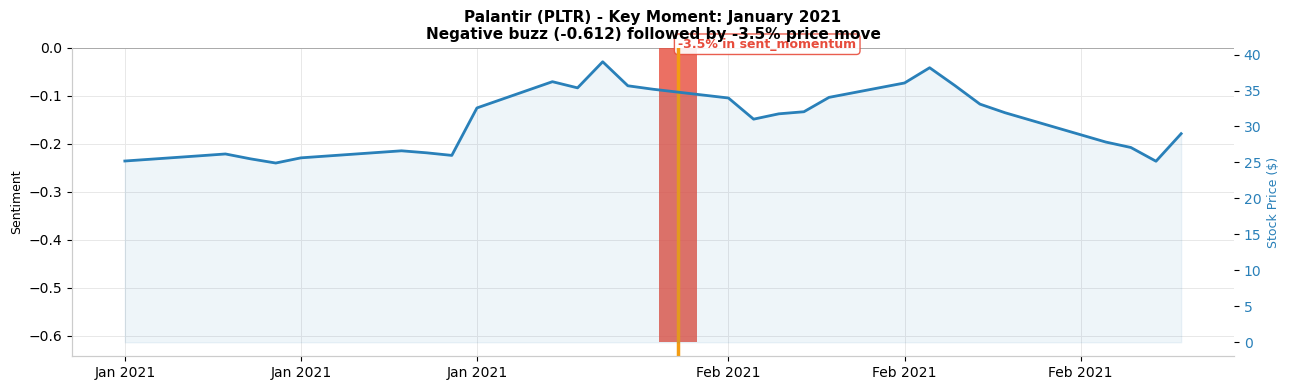


Crowdstrike (CRWD) - 3 key moments found


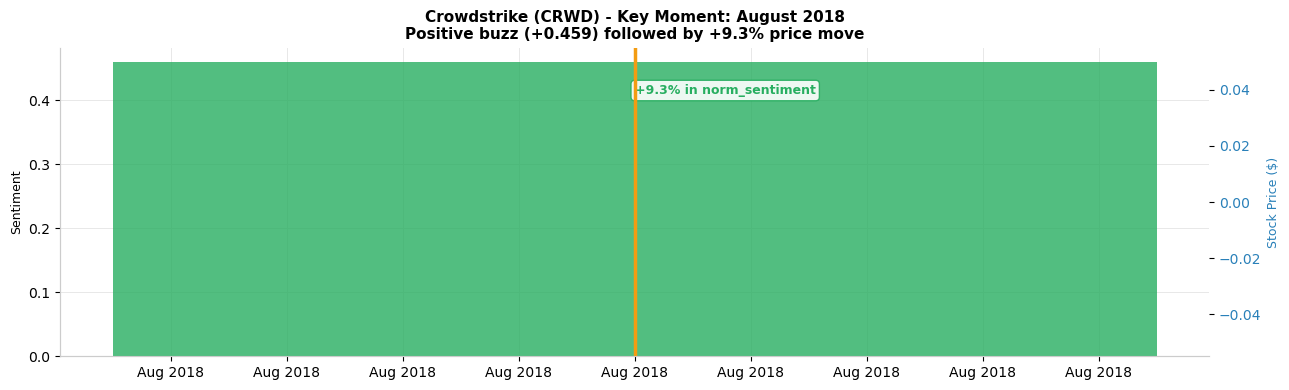

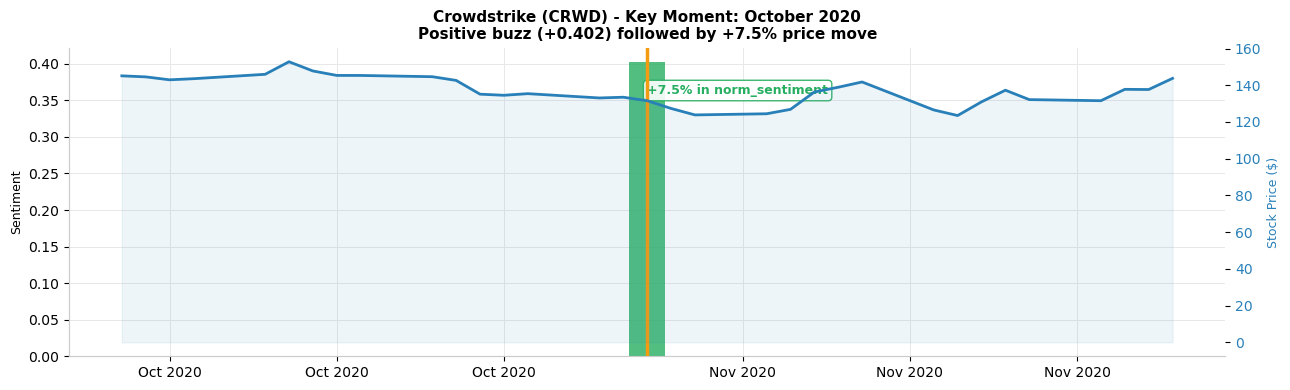

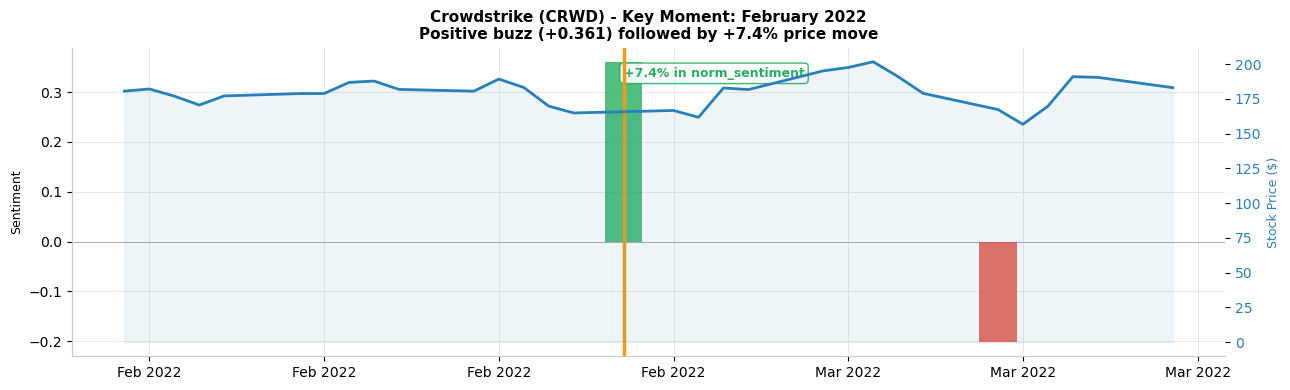


Philip Morris (PM) - 3 key moments found


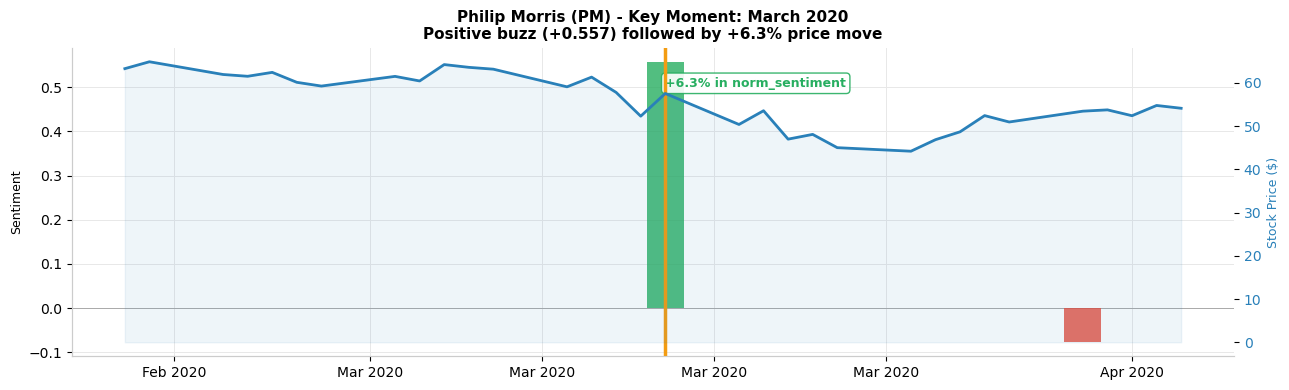

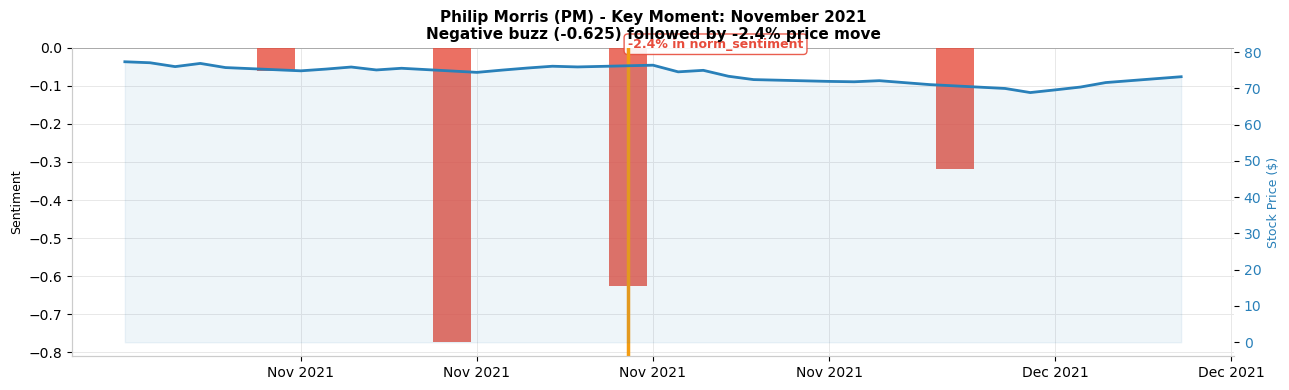

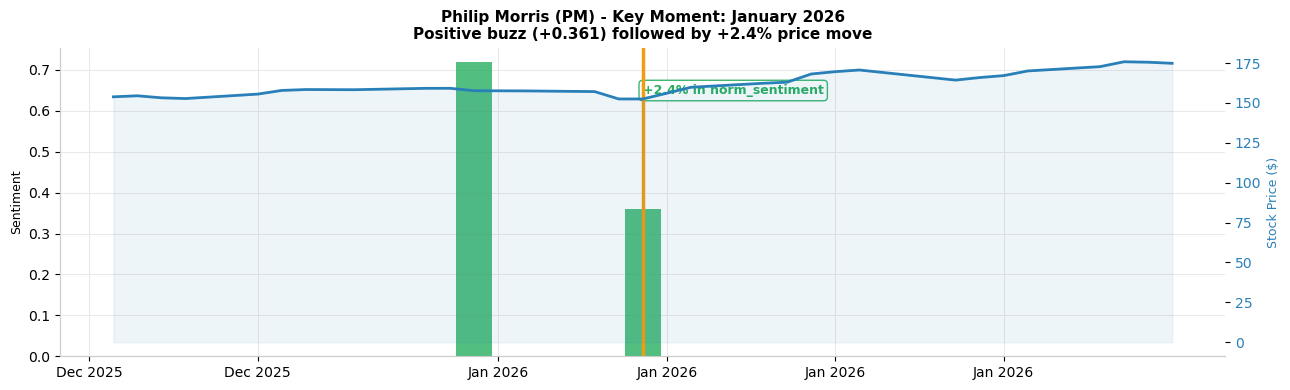

In [12]:
def find_key_moments(ticker, signal_col='sent_roll_3d', horizon=3, n_moments=3):
    sig   = daily_signals[daily_signals['ticker'] == ticker].copy()
    price = df_prices[df_prices['ticker'] == ticker].copy()
    if sig.empty or price.empty:
        return []

    price = price.set_index('Date').sort_index()
    sig   = sig.set_index('date').sort_index()

    moments = []
    sent_series = sig[signal_col].dropna()
    high_thresh = sent_series.quantile(0.90)
    low_thresh  = sent_series.quantile(0.10)

    for date, sent_val in sent_series.items():
        if not (sent_val >= high_thresh or sent_val <= low_thresh):
            continue
        future = price.index[price.index > date][:horizon]
        if len(future) < horizon:
            continue
        fwd_ret = price.loc[future[-1], 'daily_return']
        if pd.isna(fwd_ret):
            continue
        # Signal worked if: positive sentiment + positive return OR negative + negative
        signal_worked = (sent_val > 0 and fwd_ret > 0.01) or (sent_val < 0 and fwd_ret < -0.01)
        if signal_worked:
            moments.append({
                'date'      : date,
                'sentiment' : sent_val,
                'fwd_ret'   : fwd_ret,
                'direction' : 'positive' if sent_val > 0 else 'negative',
            })

    # Return strongest moments by absolute forward return
    moments = sorted(moments, key=lambda x: abs(x['fwd_ret']), reverse=True)
    # Deduplicate: keep moments at least 30 days apart
    filtered = []
    for m in moments:
        if not filtered or abs((m['date'] - filtered[-1]['date']).days) > 30:
            filtered.append(m)
        if len(filtered) >= n_moments:
            break
    return filtered


def plot_key_moment(ticker, moment, signal_col='sent_roll_3d', window_days=45):
    sig   = daily_signals[daily_signals['ticker'] == ticker].copy()
    price = df_prices[df_prices['ticker'] == ticker].copy()
    name  = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()

    sig['date']   = pd.to_datetime(sig['date'])
    price['Date'] = pd.to_datetime(price['Date'])

    event_date = pd.Timestamp(moment['date'])
    win_start  = event_date - pd.Timedelta(days=window_days//2)
    win_end    = event_date + pd.Timedelta(days=window_days//2)

    sig_w   = sig[(sig['date']   >= win_start) & (sig['date']   <= win_end)]
    price_w = price[(price['Date'] >= win_start) & (price['Date'] <= win_end)]

    fig, ax1 = plt.subplots(figsize=(13, 4), facecolor='white')
    ax2 = ax1.twinx()

    # Price area
    ax2.fill_between(price_w['Date'], price_w['Close'],
                     alpha=0.08, color='#2980b9')
    ax2.plot(price_w['Date'], price_w['Close'],
             color='#2980b9', linewidth=2, label='Stock price')
    ax2.set_ylabel('Stock Price ($)', color='#2980b9', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='#2980b9')
    ax2.grid(False)

    # Sentiment bars
    sent_vals = sig_w[signal_col]
    bar_colors = ['#27ae60' if v >= SENTIMENT_THRESHOLD
                  else ('#e74c3c' if v <= -SENTIMENT_THRESHOLD else '#bdc3c7')
                  for v in sent_vals.fillna(0)]
    ax1.bar(sig_w['date'], sent_vals, color=bar_colors, alpha=0.8, width=1.5, zorder=3)
    ax1.axhline(0, color='#aaaaaa', linewidth=0.7)
    ax1.set_ylabel('Sentiment', fontsize=9)
    ax1.set_facecolor('white')

    # Event marker
    ax1.axvline(event_date, color='#f39c12', linewidth=2.5, linestyle='-', zorder=5, label='Sentiment signal')
    direction = moment['direction']
    ret_pct   = moment['fwd_ret'] * 100
    arrow_col = '#27ae60' if ret_pct > 0 else '#e74c3c'
    ax1.annotate(
        f"{'+' if ret_pct > 0 else ''}{ret_pct:.1f}% in {signal_col}",
        xy=(event_date, ax1.get_ylim()[1] * 0.85),
        fontsize=9, color=arrow_col, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=arrow_col, alpha=0.9)
    )

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.set_title(
        f"{name} ({ticker}) - Key Moment: {event_date.strftime('%B %Y')}\n"
        f"{direction.title()} buzz ({moment['sentiment']:+.3f}) followed by {ret_pct:+.1f}% price move",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Find and plot key moments for top 5 tickers
top5_tickers = best_per_ticker.head(5)['ticker'].tolist()

print('Finding key moments for top 5 tickers ...')
for ticker in top5_tickers:
    row        = best_per_ticker[best_per_ticker['ticker']==ticker].iloc[0]
    sig_col    = row['signal']
    horizon    = int(row['horizon'])
    moments    = find_key_moments(ticker, signal_col=sig_col, horizon=horizon)
    name       = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()
    print(f'\n{name} ({ticker}) - {len(moments)} key moments found')
    for m in moments:
        plot_key_moment(ticker, m, signal_col=sig_col)

---
## 13. Strategy Comparison — 6 Ways to Trade the Buzz

Tests 6 different buy/sell rules against each other on the same stock.
All start with $1,000 and use the best sentiment signal found for each ticker.

| Strategy | Rule |
|----------|------|
| **Buy & Hold** | Buy once at start, never sell — baseline |
| **Long Only** | Invest on positive buzz, sit in cash otherwise |
| **Long + Exit** | Buy on positive buzz, SELL to cash when sentiment turns negative |
| **Long + Short** | Buy on positive buzz, SHORT on negative buzz, cash on neutral |
| **Momentum Ride** | Invest when sentiment momentum is rising, exit when falling |
| **Volume Spike** | Only act when story volume is also surging (confirms the signal) |

Running strategies for NVO using signal: sent_momentum ...


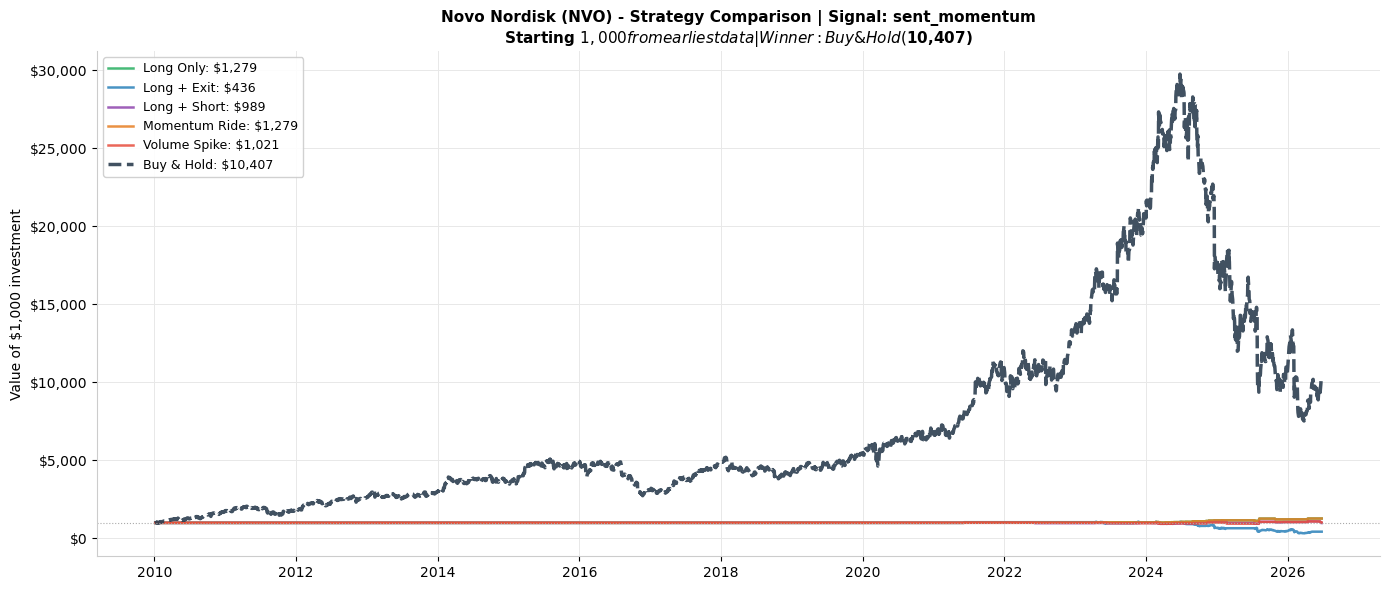


Novo Nordisk (NVO) - Summary:
     Strategy Final Value  Return vs Buy & Hold  Trades   Max Gain Max Drawdown Winner
   Buy & Hold  $10,406.78 +940.7%         +0.00       0 $28,745.40      $-19.65    YES
    Long Only   $1,279.23  +27.9%     -9,127.56      39    $279.23        $0.00       
  Long + Exit     $436.30  -56.4%     -9,970.48      24     $76.67     $-668.82       
 Long + Short     $989.29   -1.1%     -9,417.50      67     $98.11      $-63.66       
Momentum Ride   $1,279.23  +27.9%     -9,127.56      39    $279.23        $0.00       
 Volume Spike   $1,020.75   +2.1%     -9,386.04      27     $95.00      $-61.01       

Running strategies for PANW using signal: sent_momentum ...


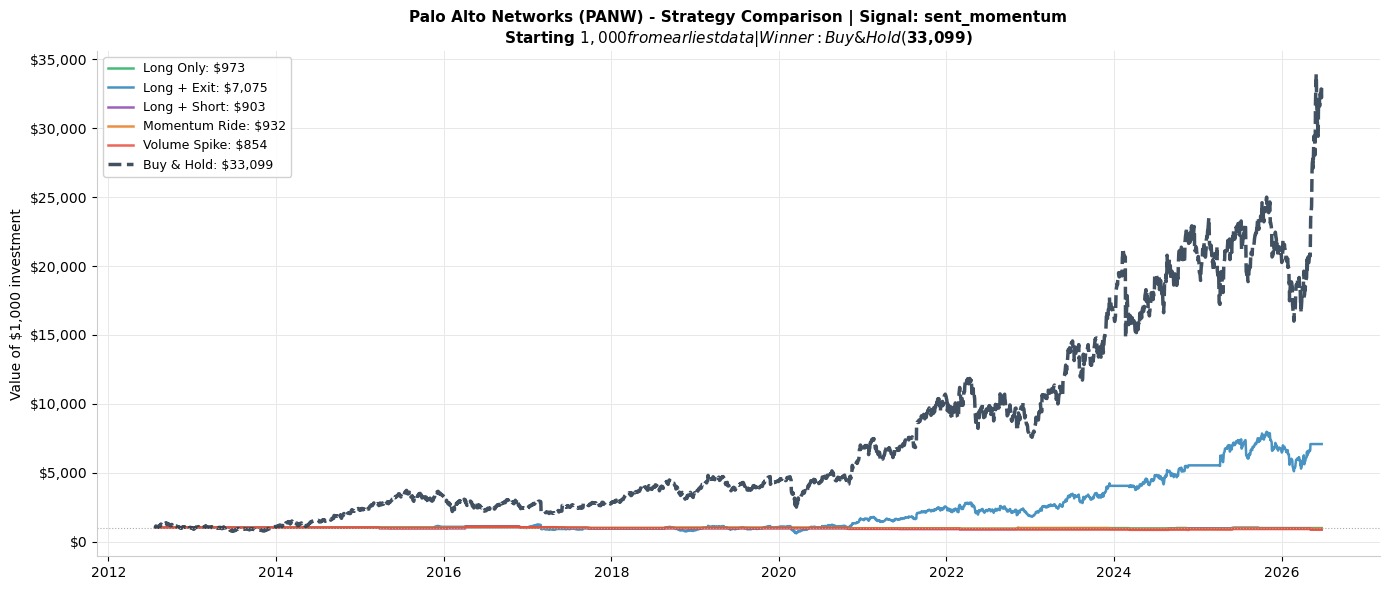


Palo Alto Networks (PANW) - Summary:
     Strategy Final Value   Return vs Buy & Hold  Trades   Max Gain Max Drawdown Winner
   Buy & Hold  $33,098.82 +3209.9%         +0.00       0 $32,933.37     $-255.41    YES
    Long Only     $973.37    -2.7%    -32,125.45      34     $47.87      $-80.40       
  Long + Exit   $7,074.52  +607.5%    -26,024.30      20  $6,969.05     $-405.63       
 Long + Short     $902.82    -9.7%    -32,196.00      51     $50.94     $-117.52       
Momentum Ride     $931.75    -6.8%    -32,167.07      35     $47.87      $-89.15       
 Volume Spike     $853.98   -14.6%    -32,244.84      24     $75.79     $-159.58       

Running strategies for PLTR using signal: sent_momentum ...


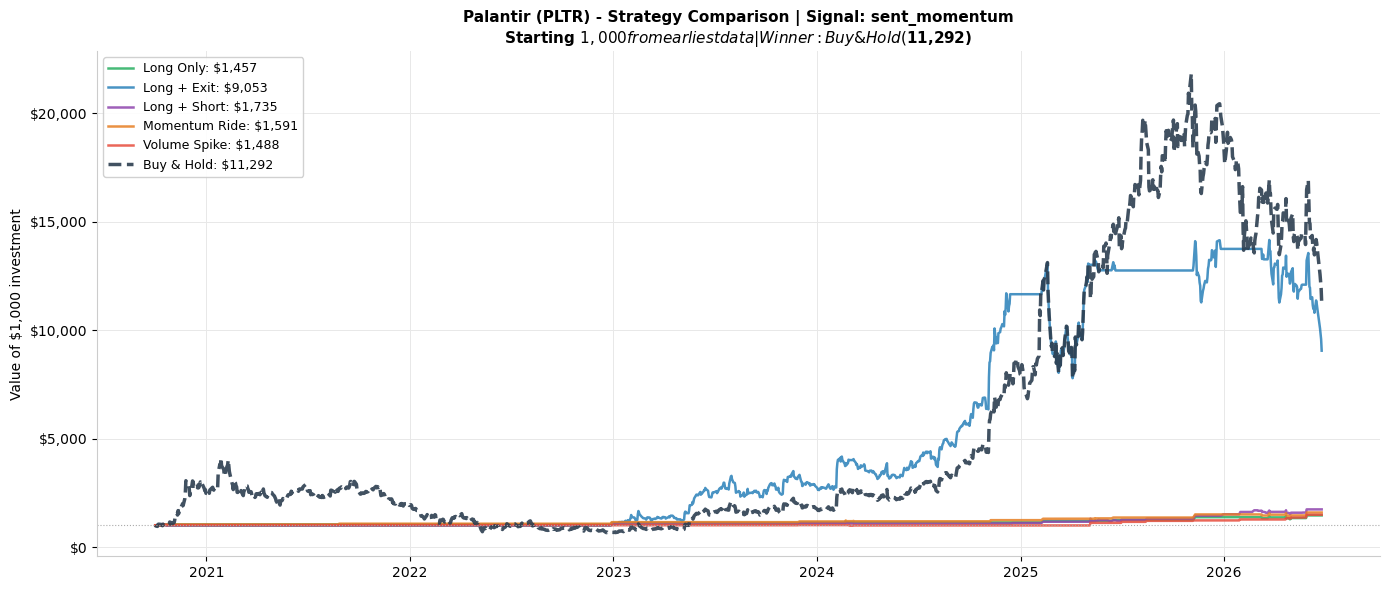


Palantir (PLTR) - Summary:
     Strategy Final Value   Return vs Buy & Hold  Trades   Max Gain Max Drawdown Winner
   Buy & Hold  $11,291.58 +1029.2%         +0.00       0 $20,808.42     $-368.42    YES
    Long Only   $1,457.21   +45.7%     -9,834.37      29    $457.21        $0.00       
  Long + Exit   $9,053.48  +805.3%     -2,238.09      19 $13,160.05      $-14.99       
 Long + Short   $1,734.85   +73.5%     -9,556.73      61    $734.85       $-5.53       
Momentum Ride   $1,591.37   +59.1%     -9,700.21      32    $591.37        $0.00       
 Volume Spike   $1,487.85   +48.8%     -9,803.73      16    $487.85      $-16.49       

Running strategies for CRWD using signal: norm_sentiment ...


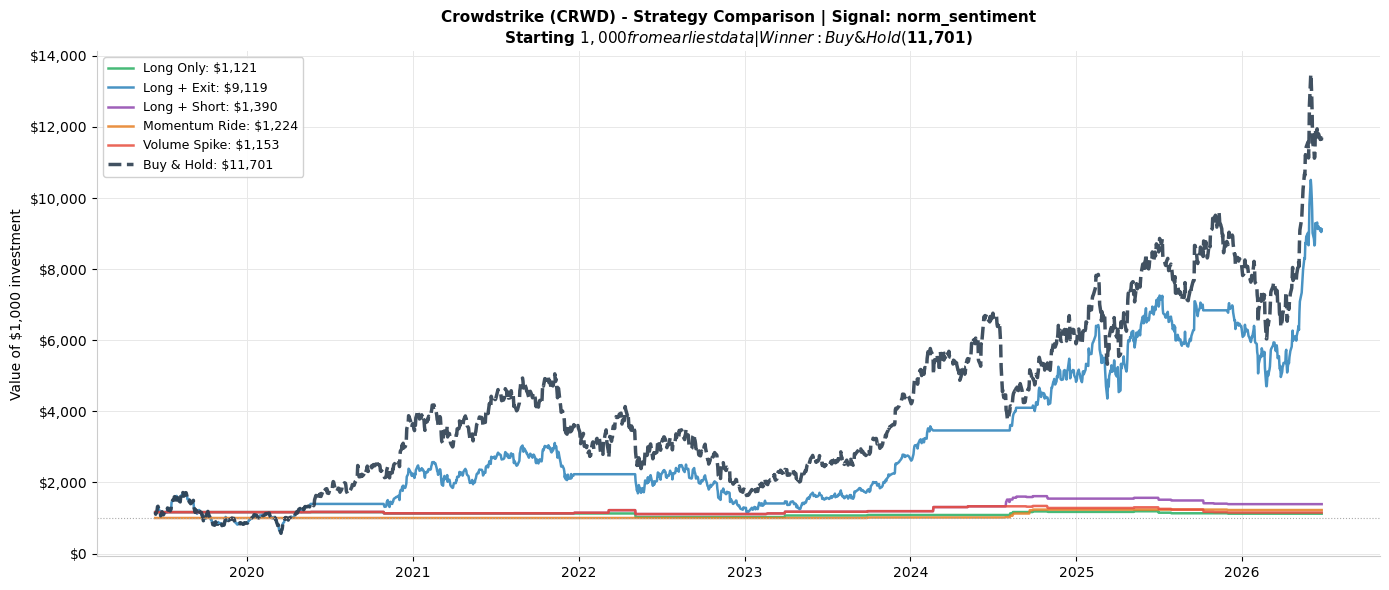


Crowdstrike (CRWD) - Summary:
     Strategy Final Value   Return vs Buy & Hold  Trades   Max Gain Max Drawdown Winner
   Buy & Hold  $11,700.86 +1070.1%         +0.00       0 $12,485.69     $-430.86    YES
    Long Only   $1,121.44   +12.1%    -10,579.43      14    $189.10        $0.00       
  Long + Exit   $9,118.67  +811.9%     -2,582.19      15  $9,509.61     $-430.86       
 Long + Short   $1,389.67   +39.0%    -10,311.20      30    $614.11        $0.00       
Momentum Ride   $1,223.87   +22.4%    -10,476.99      11    $236.08        $0.00       
 Volume Spike   $1,152.68   +15.3%    -10,548.18      22    $338.85        $0.00       

Running strategies for PM using signal: norm_sentiment ...


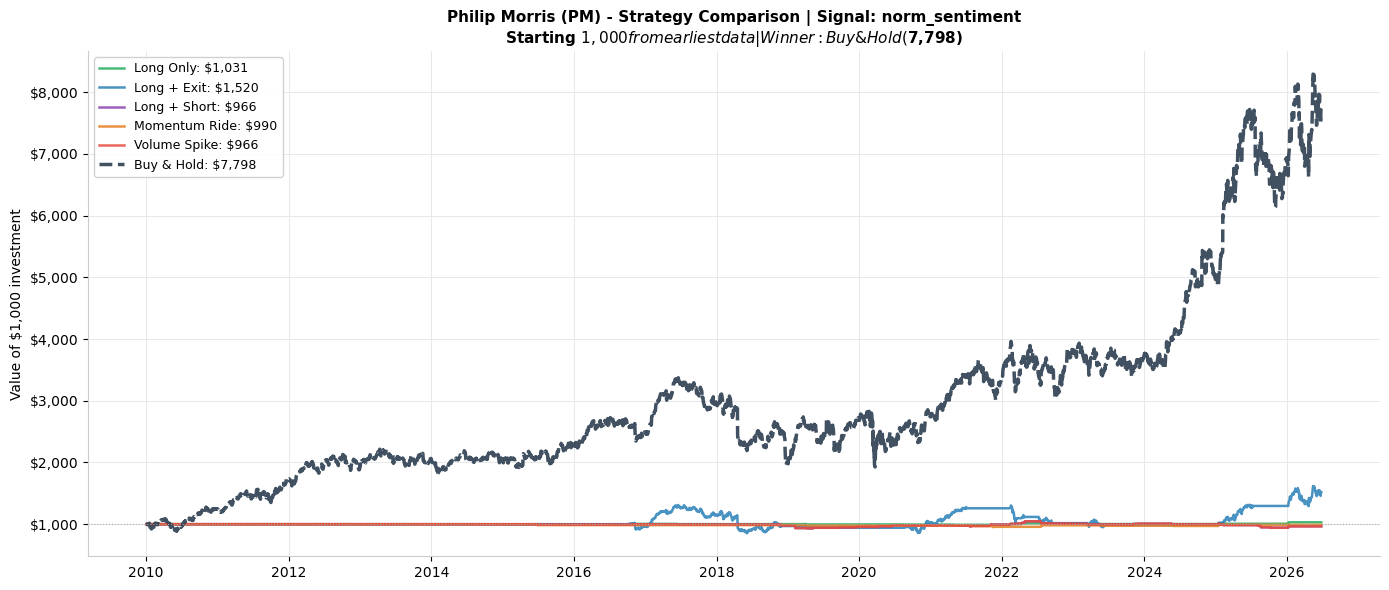


Philip Morris (PM) - Summary:
     Strategy Final Value  Return vs Buy & Hold  Trades  Max Gain Max Drawdown Winner
   Buy & Hold   $7,798.32 +679.8%         +0.00       0 $7,293.10     $-115.53    YES
    Long Only   $1,031.27   +3.1%     -6,767.05      18    $31.27       $-9.24       
  Long + Exit   $1,520.34  +52.0%     -6,277.98      21   $616.80     $-147.71       
 Long + Short     $965.73   -3.4%     -6,832.60      50    $46.88      $-66.85       
Momentum Ride     $990.11   -1.0%     -6,808.21      15     $0.00      $-47.83       
 Volume Spike     $965.73   -3.4%     -6,832.60      50    $46.88      $-66.85       

Done!


In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

STARTING_CASH = 1000
INVESTMENT_START_DATE = None   # set to e.g. '2018-01-01' to change start

# Strategy colors
STRAT_COLORS = {
    'Buy & Hold'      : '#2c3e50',
    'Long Only'       : '#27ae60',
    'Long + Exit'     : '#2980b9',
    'Long + Short'    : '#8e44ad',
    'Momentum Ride'   : '#e67e22',
    'Volume Spike'    : '#e74c3c',
}

def run_strategies(ticker, sig_col, price_df, signal_df, start_date=None):
    price = price_df[price_df['ticker'] == ticker].copy()
    sig   = signal_df[signal_df['ticker'] == ticker].copy()

    price['Date'] = pd.to_datetime(price['Date'])
    sig['date']   = pd.to_datetime(sig['date'])
    price = price.sort_values('Date').set_index('Date')
    sig   = sig.sort_values('date').set_index('date')

    if start_date:
        start = pd.Timestamp(start_date)
        price = price[price.index >= start]
        sig   = sig[sig.index >= start]

    strategies = {
        'Buy & Hold'    : STARTING_CASH,
        'Long Only'     : STARTING_CASH,
        'Long + Exit'   : STARTING_CASH,
        'Long + Short'  : STARTING_CASH,
        'Momentum Ride' : STARTING_CASH,
        'Volume Spike'  : STARTING_CASH,
    }
    history   = {k: [] for k in strategies}
    trades    = {k: 0  for k in strategies}
    max_gains = {k: 0.0 for k in strategies}
    max_losses= {k: 0.0 for k in strategies}
    dates_used = []

    # Track position state for Long+Exit
    long_exit_in_market = False

    for date in price.index:
        ret = price.loc[date, 'daily_return']
        if pd.isna(ret):
            continue

        # Get yesterday's signals
        yesterday = date - pd.Timedelta(days=1)
        prior_dates = sig.index[sig.index <= yesterday]
        if len(prior_dates) > 0:
            p = sig.loc[prior_dates[-1]]
            sent        = p[sig_col] if not pd.isna(p[sig_col]) else 0.0
            momentum    = p['sent_momentum'] if not pd.isna(p.get('sent_momentum', np.nan)) else 0.0
            vol_surge   = p['volume_surge'] if not pd.isna(p.get('volume_surge', np.nan)) else 0.0
        else:
            sent = momentum = vol_surge = 0.0

        pos_buzz = sent >= SENTIMENT_THRESHOLD
        neg_buzz = sent <= -SENTIMENT_THRESHOLD
        mom_up   = momentum > 0.02
        mom_down = momentum < -0.02
        vol_high = vol_surge > 1.0

        # ── Buy & Hold: always invested ────────────────────────────
        strategies['Buy & Hold'] *= (1 + ret)

        # ── Long Only: invest on positive buzz, cash otherwise ─────
        if pos_buzz:
            old = strategies['Long Only']
            strategies['Long Only'] *= (1 + ret)
            if strategies['Long Only'] != old:
                trades['Long Only'] += 1

        # ── Long + Exit: buy on positive, sell on negative ─────────
        if pos_buzz and not long_exit_in_market:
            long_exit_in_market = True
            trades['Long + Exit'] += 1
        elif neg_buzz and long_exit_in_market:
            long_exit_in_market = False
            trades['Long + Exit'] += 1
        if long_exit_in_market:
            strategies['Long + Exit'] *= (1 + ret)

        # ── Long + Short: long on positive, short on negative ──────
        if pos_buzz:
            strategies['Long + Short'] *= (1 + ret)
            trades['Long + Short'] += 1
        elif neg_buzz:
            strategies['Long + Short'] *= (1 - ret)  # short = profit if price drops
            trades['Long + Short'] += 1

        # ── Momentum Ride: invest when buzz is rising ───────────────
        if mom_up:
            strategies['Momentum Ride'] *= (1 + ret)
            trades['Momentum Ride'] += 1

        # ── Volume Spike: only trade when volume confirms signal ────
        if pos_buzz and vol_high:
            strategies['Volume Spike'] *= (1 + ret)
            trades['Volume Spike'] += 1
        elif neg_buzz and vol_high:
            strategies['Volume Spike'] *= (1 - ret)
            trades['Volume Spike'] += 1

        # Track history and max gain/loss
        for k in strategies:
            history[k].append(strategies[k])
            gain = strategies[k] - STARTING_CASH
            if gain > max_gains[k]:  max_gains[k]  = gain
            if gain < max_losses[k]: max_losses[k] = gain

        dates_used.append(date)

    return strategies, history, trades, max_gains, max_losses, dates_used


def plot_strategy_comparison(ticker, sig_col):
    name = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()
    finals, history, trades, max_gains, max_losses, dates = run_strategies(
        ticker, sig_col, df_prices, daily_signals, INVESTMENT_START_DATE
    )
    if not dates:
        print(f'  {ticker}: no data')
        return None

    # ── Chart ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')

    # Draw buy & hold last so it's always visible
    for strat, vals in history.items():
        if strat == 'Buy & Hold':
            continue
        ax.plot(dates, vals, linewidth=1.8, color=STRAT_COLORS[strat],
                label=f"{strat}: ${finals[strat]:,.0f}", alpha=0.85)
    ax.plot(dates, history['Buy & Hold'], linewidth=2.5,
            color=STRAT_COLORS['Buy & Hold'], linestyle='--',
            label=f"Buy & Hold: ${finals['Buy & Hold']:,.0f}", alpha=0.9)

    ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.8, linestyle=':')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_ylabel('Value of $1,000 investment', fontsize=10)
    ax.set_facecolor('white')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    winner = max(finals, key=finals.get)
    start_label = INVESTMENT_START_DATE or 'earliest data'
    ax.set_title(
        f"{name} ({ticker}) - Strategy Comparison | Signal: {sig_col}\n"
        f"Starting ${STARTING_CASH:,} from {start_label} | Winner: {winner} (${finals[winner]:,.0f})",
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9, loc='upper left', facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────
    rows = []
    for strat in STRAT_COLORS:
        final    = finals[strat]
        ret_pct  = (final / STARTING_CASH - 1) * 100
        vs_hold  = final - finals['Buy & Hold']
        rows.append({
            'Strategy'       : strat,
            'Final Value'    : f'${final:,.2f}',
            'Return'         : f'{ret_pct:+.1f}%',
            'vs Buy & Hold'  : f'{vs_hold:+,.2f}',
            'Trades'         : trades[strat],
            'Max Gain'       : f'${max_gains[strat]:,.2f}',
            'Max Drawdown'   : f'${max_losses[strat]:,.2f}',
            'Winner'         : 'YES' if strat == winner else '',
        })
    df_table = pd.DataFrame(rows)
    print(f'\n{name} ({ticker}) - Summary:')
    print(df_table.to_string(index=False))
    print()
    return df_table


# Run for top 5 tickers
top5 = best_per_ticker.head(5)['ticker'].tolist()
all_summaries = []
for ticker in top5:
    row     = best_per_ticker[best_per_ticker['ticker'] == ticker]
    if row.empty: continue
    sig_col = row.iloc[0]['signal']
    print(f'Running strategies for {ticker} using signal: {sig_col} ...')
    summary = plot_strategy_comparison(ticker, sig_col)
    if summary is not None:
        summary.insert(0, 'Ticker', ticker)
        all_summaries.append(summary)

print('Done!')

---
## 14. Overall Strategy Winner

Across all tickers, which strategy won most often and made the most money on average?

STRATEGY LEADERBOARD (across all tickers)
               Wins  Avg Return (%)  Avg Trades
Strategy                                       
Buy & Hold      5.0          1385.9         0.0
Long + Exit     0.0           444.1        19.8
Momentum Ride   0.0            20.3        26.4
Long + Short    0.0            19.7        51.8
Long Only       0.0            17.2        26.8
Volume Spike    0.0             9.6        27.8


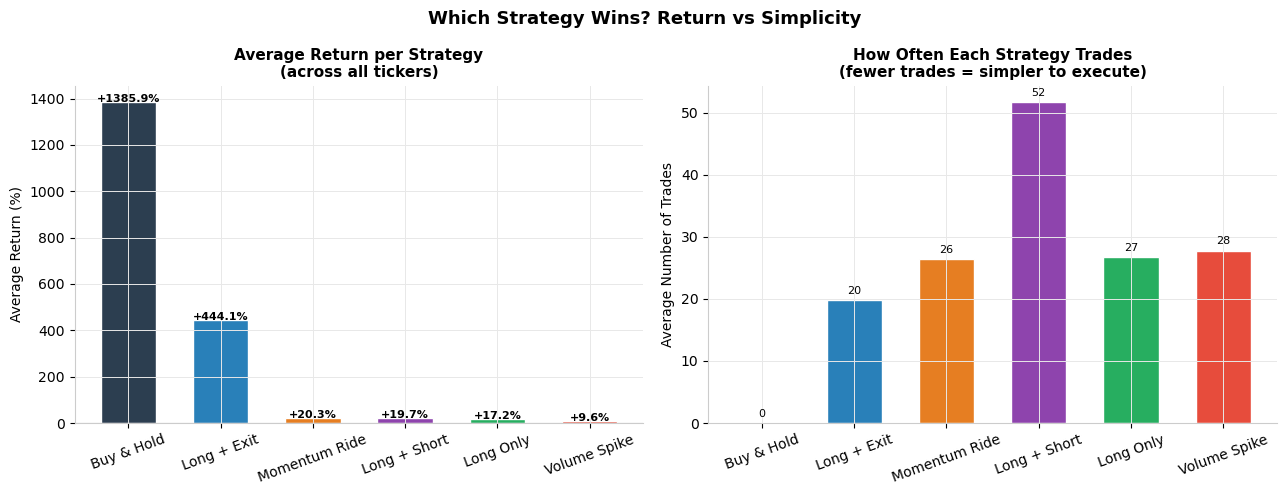


Note: More trades = more transaction costs in real life.
A strategy with slightly lower returns but far fewer trades
may actually be better once real costs are factored in.


In [14]:
if all_summaries:
    df_all = pd.concat(all_summaries, ignore_index=True)

    # Parse final value back to float for aggregation
    df_all['final_val'] = df_all['Final Value'].str.replace('[$,]', '', regex=True).astype(float)
    df_all['ret_val']   = df_all['Return'].str.replace('%', '').astype(float)

    # Win count and average return per strategy
    win_counts = df_all[df_all['Winner']=='YES'].groupby('Strategy').size().rename('Wins')
    avg_return = df_all.groupby('Strategy')['ret_val'].mean().rename('Avg Return (%)')
    avg_trades = df_all.groupby('Strategy')['Trades'].mean().rename('Avg Trades')

    leaderboard = pd.concat([win_counts, avg_return, avg_trades], axis=1).fillna(0)
    leaderboard['Avg Return (%)'] = leaderboard['Avg Return (%)'].round(1)
    leaderboard['Avg Trades']     = leaderboard['Avg Trades'].round(1)
    leaderboard = leaderboard.sort_values('Avg Return (%)', ascending=False)

    print('='*60)
    print('STRATEGY LEADERBOARD (across all tickers)')
    print('='*60)
    print(leaderboard.to_string())

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

    ax = axes[0]
    colors = [STRAT_COLORS.get(s, '#888888') for s in leaderboard.index]
    bars = ax.bar(leaderboard.index, leaderboard['Avg Return (%)'],
                  color=colors, edgecolor='white', width=0.6)
    ax.axhline(0, color='#aaaaaa', linewidth=0.8)
    ax.set_ylabel('Average Return (%)', fontsize=10)
    ax.set_title('Average Return per Strategy\n(across all tickers)',
                 fontsize=11, fontweight='bold')
    ax.set_facecolor('white')
    ax.tick_params(axis='x', labelrotation=20)
    for bar, val in zip(bars, leaderboard['Avg Return (%)']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:+.1f}%', ha='center', fontsize=8, fontweight='bold')

    ax = axes[1]
    bars2 = ax.bar(leaderboard.index, leaderboard['Avg Trades'],
                   color=colors, edgecolor='white', width=0.6)
    ax.set_ylabel('Average Number of Trades', fontsize=10)
    ax.set_title('How Often Each Strategy Trades\n(fewer trades = simpler to execute)',
                 fontsize=11, fontweight='bold')
    ax.set_facecolor('white')
    ax.tick_params(axis='x', labelrotation=20)
    for bar, val in zip(bars2, leaderboard['Avg Trades']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{val:.0f}', ha='center', fontsize=8)

    fig.suptitle('Which Strategy Wins? Return vs Simplicity',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nNote: More trades = more transaction costs in real life.')
    print('A strategy with slightly lower returns but far fewer trades')
    print('may actually be better once real costs are factored in.')

---
## 15. Position Trader Analysis

Shifts from day-trading to position-trading — longer holds, fewer trades, higher conviction signals.

**Key differences from the day-trader approach:**
- Holds last **1, 2, or 4 weeks** after a signal fires
- Only acts on **high-conviction buzz** (strong sentiment threshold)
- Requires **buzz consensus** (minimum story count before acting)
- Compares all combinations so you can see which hold length works best

**Configuration** — adjust these before running:

In [15]:
# ── Position Trader Configuration ────────────────────────────────────
# Adjust these to explore different strategies

HOLD_PERIODS      = [5, 10, 21]     # trading days to hold: ~1 week, 2 weeks, 1 month
SENT_THRESHOLDS   = [0.05, 0.2, 0.4, 0.6]  # min sentiment score to trigger a buy
MIN_STORY_COUNTS  = [1, 3, 5, 10]   # min stories mentioning company to trust signal
POSITION_CASH     = 1000            # starting cash
POSITION_START    = None            # set to 'YYYY-MM-DD' or None for all data

print('Position trader configuration loaded')
print(f'  Hold periods    : {HOLD_PERIODS} trading days')
print(f'  Sent thresholds : {SENT_THRESHOLDS}')
print(f'  Min story counts: {MIN_STORY_COUNTS}')
print(f'  Starting cash   : ${POSITION_CASH:,}')

Position trader configuration loaded
  Hold periods    : [5, 10, 21] trading days
  Sent thresholds : [0.05, 0.2, 0.4, 0.6]
  Min story counts: [1, 3, 5, 10]
  Starting cash   : $1,000


---
## 16. Threshold & Consensus Sweep

Sweeps across sentiment thresholds and minimum story counts to find the sweet spot.
For each combination, computes the win rate (% of signals where stock went up during hold period).

In [16]:
from scipy import stats as scipy_stats

def compute_signal_quality(ticker, sig_col, hold_days, sent_thresh, min_stories):
    """
    For a given threshold and consensus requirement, find all days where
    sentiment fired AND story count met the bar, then check if the stock
    was higher hold_days later.
    Returns: win_rate, avg_return, n_signals
    """
    sig   = daily_signals[daily_signals['ticker'] == ticker].copy()
    price = df_prices[df_prices['ticker'] == ticker].copy()
    if sig.empty or price.empty:
        return np.nan, np.nan, 0

    sig['date']   = pd.to_datetime(sig['date'])
    price['Date'] = pd.to_datetime(price['Date'])
    price = price.set_index('Date').sort_index()
    sig   = sig.set_index('date').sort_index()

    wins, losses, returns = 0, 0, []

    last_signal_date = None

    for date, row in sig.iterrows():
        sent_val    = row.get(sig_col, np.nan)
        story_count = row.get('story_count', 0)

        if pd.isna(sent_val) or story_count < min_stories:
            continue
        if sent_val < sent_thresh:
            continue
        # Don't overlap holds — skip if still in a position
        if last_signal_date and (date - last_signal_date).days < hold_days:
            continue

        # Get price hold_days forward
        future = price.index[price.index > date]
        if len(future) < hold_days:
            continue
        exit_date  = future[hold_days - 1]
        entry_price = price.loc[price.index[price.index > date][0], 'Close']
        exit_price  = price.loc[exit_date, 'Close']
        ret = (exit_price - entry_price) / entry_price

        returns.append(ret)
        if ret > 0: wins += 1
        else: losses += 1
        last_signal_date = date

    n = len(returns)
    if n == 0:
        return np.nan, np.nan, 0
    return wins / n, np.mean(returns) * 100, n


# Sweep across thresholds and story counts for top 5 tickers
print('Running threshold x consensus sweep ...')
print('(This may take a minute)')

sweep_results = []
top5 = best_per_ticker.head(5)['ticker'].tolist()

for ticker in top5:
    row = best_per_ticker[best_per_ticker['ticker'] == ticker]
    if row.empty: continue
    sig_col = row.iloc[0]['signal']

    for hold in HOLD_PERIODS:
        for thresh in SENT_THRESHOLDS:
            for min_s in MIN_STORY_COUNTS:
                win_rate, avg_ret, n_sigs = compute_signal_quality(
                    ticker, sig_col, hold, thresh, min_s
                )
                sweep_results.append({
                    'ticker'      : ticker,
                    'signal'      : sig_col,
                    'hold_days'   : hold,
                    'sent_thresh' : thresh,
                    'min_stories' : min_s,
                    'win_rate'    : win_rate,
                    'avg_return'  : avg_ret,
                    'n_signals'   : n_sigs,
                })

df_sweep = pd.DataFrame(sweep_results).dropna(subset=['win_rate'])
print(f'Sweep complete: {len(df_sweep):,} combinations tested')

# Best combo per ticker
best_combos = (
    df_sweep[df_sweep['n_signals'] >= 3]
    .sort_values('avg_return', ascending=False)
    .drop_duplicates(subset='ticker')
    .reset_index(drop=True)
)
print('\nBest parameter combo per ticker:')
print(best_combos[['ticker','hold_days','sent_thresh','min_stories',
                    'win_rate','avg_return','n_signals']]
      .round({'win_rate':3,'avg_return':2})
      .to_string(index=False))

Running threshold x consensus sweep ...
(This may take a minute)
Sweep complete: 90 combinations tested

Best parameter combo per ticker:
ticker  hold_days  sent_thresh  min_stories  win_rate  avg_return  n_signals
  PLTR         21          0.6            1     1.000       20.57          4
  CRWD         21          0.2            1     0.765       10.43         17
    PM         21          0.6            1     0.500        9.08          4
  PANW         21          0.2            1     0.750        7.40         12
   NVO         21          0.4            1     0.600        5.54          5


---
## 17. Sweep Heatmaps

For each ticker, shows win rate across all threshold × hold period combinations.
Darker green = buzz signal was more reliable at that combination.

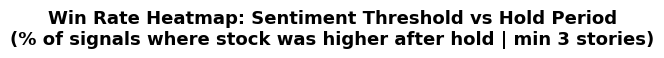

Above 50% = signal beat random chance for that combination
Above 60% = strong signal worth acting on


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, len(top5), figsize=(5*len(top5), 5), facecolor='white')
if len(top5) == 1: axes = [axes]

for ax, ticker in zip(axes, top5):
    name = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()
    sub  = df_sweep[
        (df_sweep['ticker'] == ticker) &
        (df_sweep['min_stories'] == 3) &  # fix consensus at 3 for this view
        (df_sweep['n_signals'] >= 3)
    ]
    if sub.empty:
        ax.set_visible(False)
        continue
    pivot = sub.pivot_table(
        index='sent_thresh', columns='hold_days',
        values='win_rate', aggfunc='mean'
    )
    pivot.columns = [f'{c}d hold' for c in pivot.columns]
    pivot.index   = [f'>{v}' for v in pivot.index]
    sns.heatmap(
        pivot, annot=True, fmt='.0%', cmap='RdYlGn',
        vmin=0.3, vmax=0.7, ax=ax, linewidths=0.5,
        cbar=False
    )
    ax.set_title(f'{name}\n({ticker})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Hold period', fontsize=9)
    ax.set_ylabel('Sentiment threshold', fontsize=9)
    ax.set_facecolor('white')

fig.suptitle(
    'Win Rate Heatmap: Sentiment Threshold vs Hold Period\n'
    '(% of signals where stock was higher after hold | min 3 stories)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()
print('Above 50% = signal beat random chance for that combination')
print('Above 60% = strong signal worth acting on')

---
## 18. Position Trader Backtest

Uses the best threshold + hold period found in the sweep to run a full backtest.
Compares the position strategy against buy & hold over the full period.

**How it works:**
- Waits for a high-conviction signal (buzz above threshold AND enough stories)
- Buys in and holds for the full hold period
- Does NOT exit early — holds for the full window regardless of what happens
- Sits in cash between signals
- Never overlaps positions

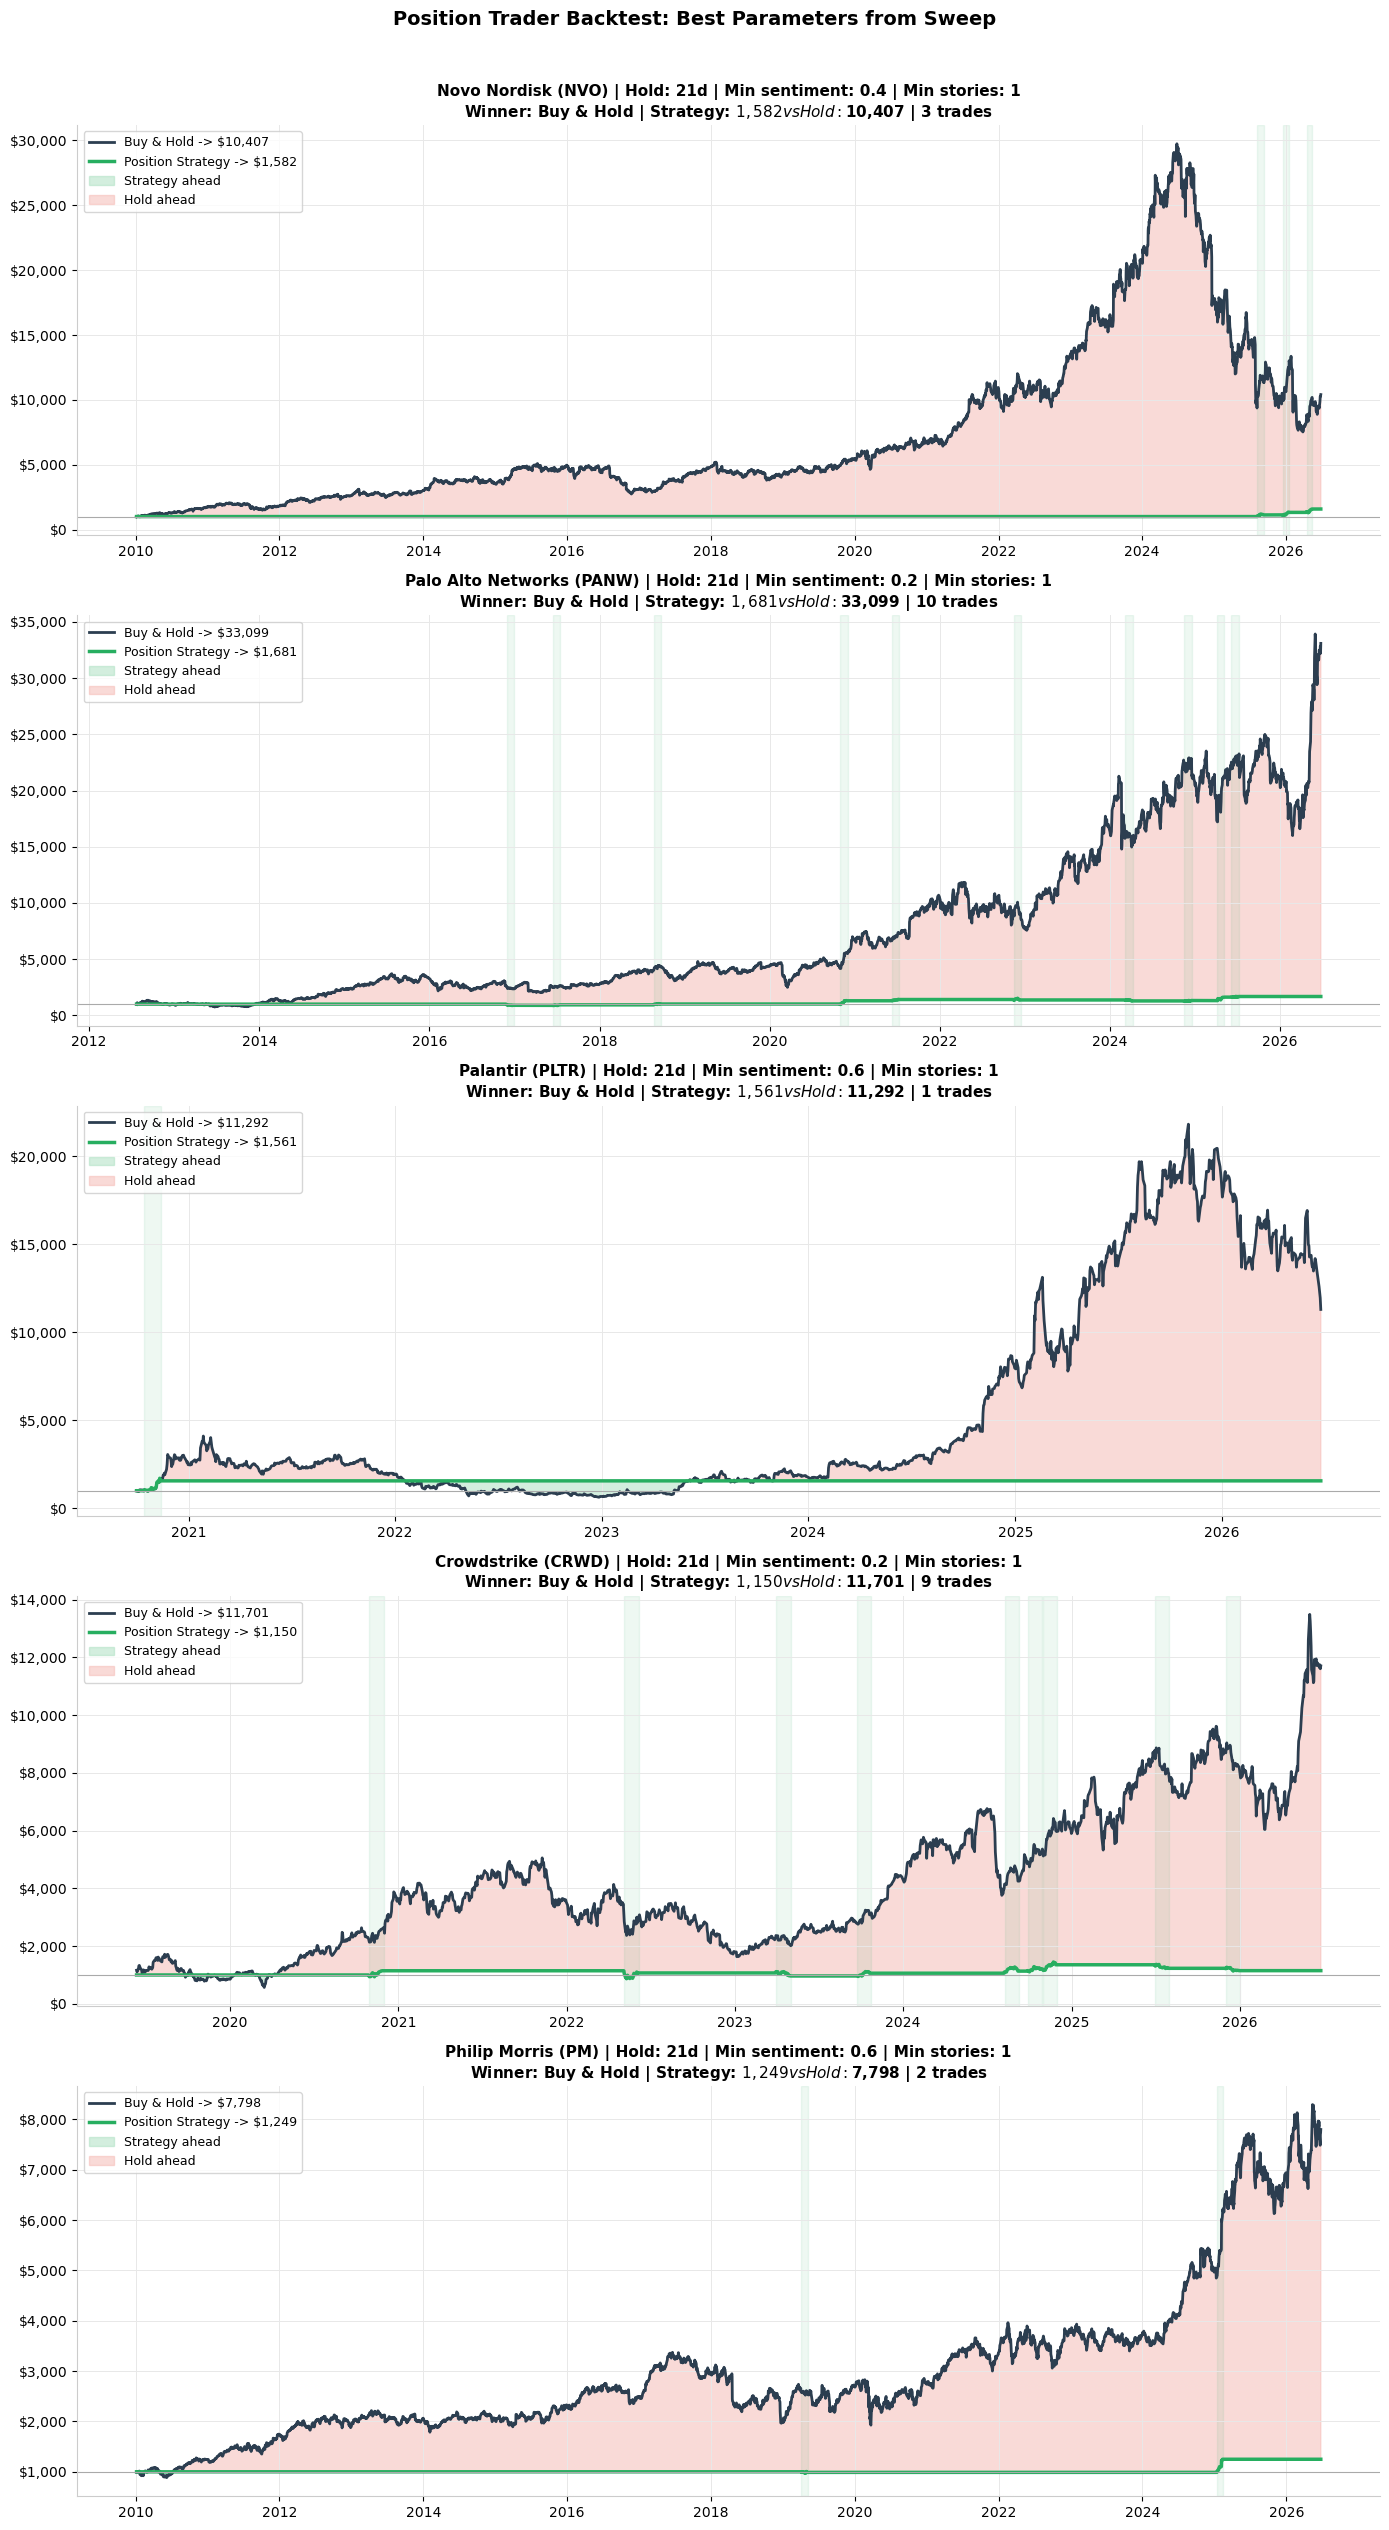

In [18]:
def run_position_backtest(ticker, sig_col, hold_days, sent_thresh,
                          min_stories, start_date=None):
    sig   = daily_signals[daily_signals['ticker'] == ticker].copy()
    price = df_prices[df_prices['ticker'] == ticker].copy()
    name  = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()

    sig['date']   = pd.to_datetime(sig['date'])
    price['Date'] = pd.to_datetime(price['Date'])
    price = price.sort_values('Date').set_index('Date')
    sig   = sig.sort_values('date').set_index('date')

    if start_date:
        start = pd.Timestamp(start_date)
        price = price[price.index >= start]
        sig   = sig[sig.index >= start]

    cash       = POSITION_CASH
    hold_cash  = POSITION_CASH
    position_end = None   # date when current hold expires
    in_position  = False
    entry_price  = None

    buzz_history = []
    hold_history = []
    dates_used   = []
    trade_log    = []   # record every trade

    for date in price.index:
        ret = price.loc[date, 'daily_return']
        if pd.isna(ret): continue

        # Buy & hold baseline
        hold_cash *= (1 + ret)

        # Check if position has expired
        if in_position and position_end and date >= position_end:
            exit_price = price.loc[date, 'Close']
            trade_ret  = (exit_price - entry_price) / entry_price
            trade_log.append({
                'entry_date' : position_start_date,
                'exit_date'  : date,
                'entry_price': round(entry_price, 2),
                'exit_price' : round(exit_price, 2),
                'return_pct' : round(trade_ret * 100, 2),
                'hold_days'  : hold_days,
            })
            in_position  = False
            position_end = None

        # While in position, ride the return
        if in_position:
            cash *= (1 + ret)

        # Look for new signal if not in position
        elif not in_position:
            yesterday = date - pd.Timedelta(days=1)
            prior     = sig.index[sig.index <= yesterday]
            if len(prior) > 0:
                p = sig.loc[prior[-1]]
                sent_val    = p.get(sig_col, np.nan)
                story_count = p.get('story_count', 0)
                if (not pd.isna(sent_val) and
                    sent_val >= sent_thresh and
                    story_count >= min_stories):
                    # Enter position
                    in_position       = True
                    entry_price       = price.loc[date, 'Close']
                    position_start_date = date
                    future_dates      = price.index[price.index > date]
                    position_end      = future_dates[hold_days-1] if len(future_dates) >= hold_days else future_dates[-1]
                    cash *= (1 + ret)

        buzz_history.append(cash)
        hold_history.append(hold_cash)
        dates_used.append(date)

    return cash, hold_cash, buzz_history, hold_history, dates_used, pd.DataFrame(trade_log)


# Run backtest using best params from sweep
fig, axes = plt.subplots(len(top5), 1,
                          figsize=(14, 5*len(top5)), facecolor='white')
if len(top5) == 1: axes = [axes]

all_trade_logs = []

for ax, ticker in zip(axes, top5):
    brow = best_per_ticker[best_per_ticker['ticker']==ticker]
    if brow.empty: continue
    sig_col = brow.iloc[0]['signal']
    name    = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()

    # Get best params from sweep
    srow = best_combos[best_combos['ticker']==ticker]
    if srow.empty:
        hold_d  = HOLD_PERIODS[1]
        thresh  = SENT_THRESHOLDS[1]
        min_s   = MIN_STORY_COUNTS[1]
    else:
        hold_d  = int(srow.iloc[0]['hold_days'])
        thresh  = float(srow.iloc[0]['sent_thresh'])
        min_s   = int(srow.iloc[0]['min_stories'])

    final_buzz, final_hold, buzz_h, hold_h, dates_u, trade_log = run_position_backtest(
        ticker, sig_col, hold_d, thresh, min_s, POSITION_START
    )

    if trade_log is not None and not trade_log.empty:
        trade_log['ticker'] = ticker
        all_trade_logs.append(trade_log)

    # Plot
    ax.plot(dates_u, hold_h, color='#2c3e50', linewidth=2,
            label=f'Buy & Hold -> ${final_hold:,.0f}')
    ax.plot(dates_u, buzz_h, color='#27ae60', linewidth=2.5,
            label=f'Position Strategy -> ${final_buzz:,.0f}')
    ax.fill_between(dates_u, hold_h, buzz_h,
                    where=[b>h for b,h in zip(buzz_h,hold_h)],
                    color='#a9dfbf', alpha=0.5, label='Strategy ahead')
    ax.fill_between(dates_u, hold_h, buzz_h,
                    where=[b<h for b,h in zip(buzz_h,hold_h)],
                    color='#f5b7b1', alpha=0.5, label='Hold ahead')
    ax.axhline(POSITION_CASH, color='#aaaaaa', linewidth=0.8)

    # Mark trade entries on chart
    if trade_log is not None and not trade_log.empty:
        for _, trade in trade_log.iterrows():
            ax.axvspan(trade['entry_date'], trade['exit_date'],
                       alpha=0.08, color='#27ae60')

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_facecolor('white')
    n_trades = len(trade_log) if trade_log is not None else 0
    winner   = 'Strategy' if final_buzz > final_hold else 'Buy & Hold'
    ax.set_title(
        f'{name} ({ticker}) | Hold: {hold_d}d | Min sentiment: {thresh} | Min stories: {min_s}\n'
        f'Winner: {winner} | Strategy: ${final_buzz:,.0f} vs Hold: ${final_hold:,.0f} | {n_trades} trades',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9, loc='upper left', facecolor='white')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Position Trader Backtest: Best Parameters from Sweep',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 19. Trade Log & Analysis

Shows every trade the position strategy made — entry date, exit date, and return.
Helps you understand what kinds of events triggered buys and whether the exits were clean.

Total trades across all tickers: 25
Win rate: 72.0%
Avg return per trade: 8.93%
Best trade : 59.4%
Worst trade: -14.9%

entry_date  exit_date  entry_price  exit_price  return_pct  hold_days ticker
2020-10-15 2020-11-13         9.91       15.80       59.43         21   PLTR
2020-10-30 2020-12-01        36.87       49.14       33.29         21   PANW
2025-01-13 2025-02-12       111.61      142.31       27.51         21     PM
2025-04-07 2025-05-07       152.44      188.14       23.42         21   PANW
2020-10-29 2020-11-30       127.36      153.28       20.35         21   CRWD
2025-12-15 2026-01-15        48.59       55.10       13.40         21    NVO
2024-10-30 2024-11-29       307.45      345.97       12.53         21   CRWD
2026-04-15 2026-05-14        40.81       45.80       12.23         21    NVO
2023-09-22 2023-10-23       162.57      179.08       10.16         21   CRWD
2021-06-08 2021-07-08        58.89       64.42        9.39         21   PANW
2018-08-21 2018-09-20        35.3

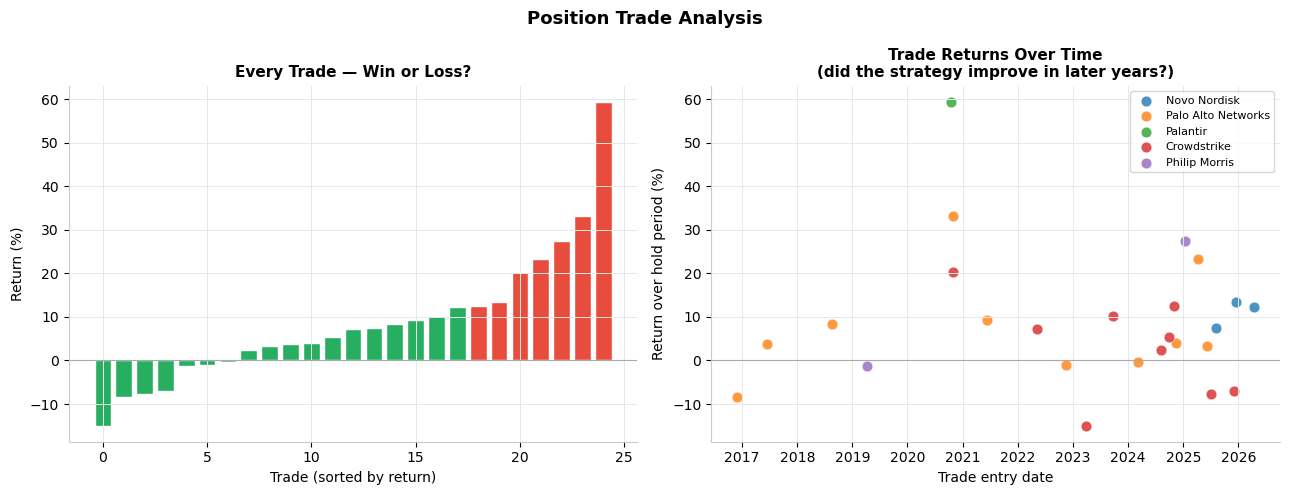

In [19]:
if all_trade_logs:
    df_trades = pd.concat(all_trade_logs, ignore_index=True)
    df_trades['entry_date'] = pd.to_datetime(df_trades['entry_date'])
    df_trades['exit_date']  = pd.to_datetime(df_trades['exit_date'])

    print(f'Total trades across all tickers: {len(df_trades)}')
    print(f'Win rate: {(df_trades["return_pct"] > 0).mean():.1%}')
    print(f'Avg return per trade: {df_trades["return_pct"].mean():.2f}%')
    print(f'Best trade : {df_trades["return_pct"].max():.1f}%')
    print(f'Worst trade: {df_trades["return_pct"].min():.1f}%')
    print()
    print(df_trades.sort_values('return_pct', ascending=False).to_string(index=False))

    # Distribution of returns
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

    ax = axes[0]
    colors = ['#27ae60' if v > 0 else '#e74c3c' for v in df_trades['return_pct']]
    ax.bar(range(len(df_trades)), df_trades.sort_values('return_pct')['return_pct'],
           color=sorted(colors), edgecolor='white')
    ax.axhline(0, color='#aaaaaa', linewidth=0.8)
    ax.set_xlabel('Trade (sorted by return)', fontsize=10)
    ax.set_ylabel('Return (%)', fontsize=10)
    ax.set_title('Every Trade — Win or Loss?', fontsize=11, fontweight='bold')
    ax.set_facecolor('white')

    ax = axes[1]
    for ticker in df_trades['ticker'].unique():
        sub = df_trades[df_trades['ticker']==ticker]
        name = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()
        ax.scatter(sub['entry_date'], sub['return_pct'],
                   label=name, alpha=0.8, s=60, edgecolors='white', linewidths=0.5)
    ax.axhline(0, color='#aaaaaa', linewidth=0.8)
    ax.set_xlabel('Trade entry date', fontsize=10)
    ax.set_ylabel('Return over hold period (%)', fontsize=10)
    ax.set_title('Trade Returns Over Time\n(did the strategy improve in later years?)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, facecolor='white')
    ax.set_facecolor('white')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    fig.suptitle('Position Trade Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 20. Relative Sentiment Signal

Instead of asking 'is buzz positive today?' this asks:
'Is buzz MORE positive than usual for this stock?'

A company that's normally talked about negatively having a positive week
may be more meaningful than a company that always gets good press.

Computes a **z-score of sentiment vs the stock's own 90-day baseline**.

Computing relative sentiment signals ...
Relative sentiment computed for 5 tickers


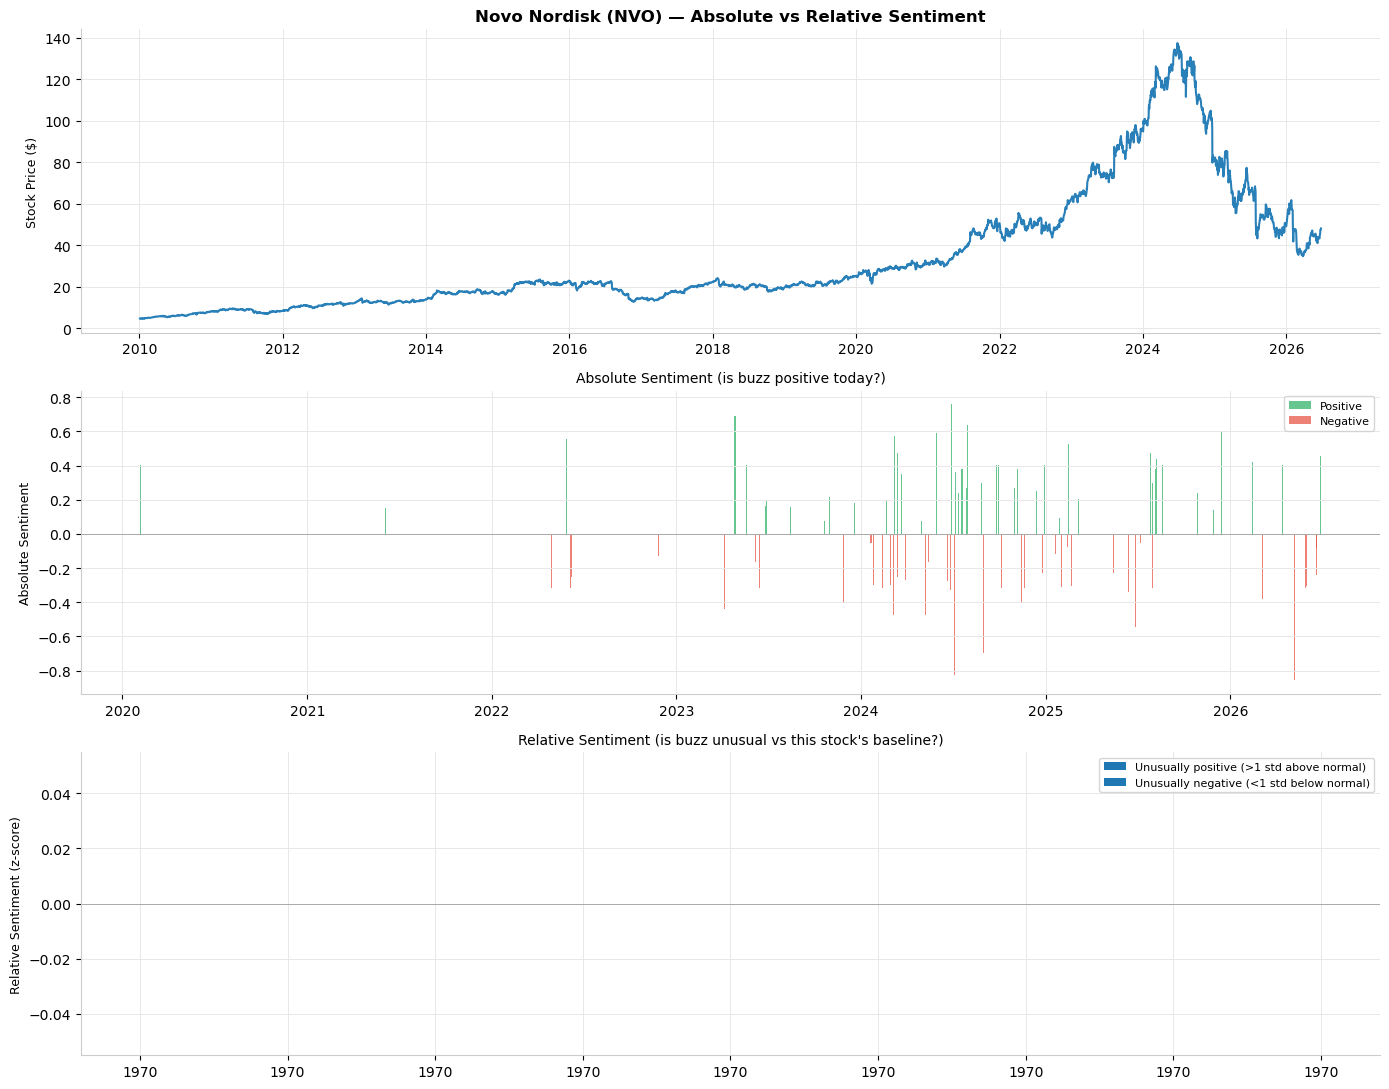


The relative sentiment chart shows when buzz was UNUSUALLY positive/negative
vs what is normal for this stock. These spikes may be more informative signals.


In [20]:
print('Computing relative sentiment signals ...')

rel_frames = []
for ticker in top5:
    sig = daily_signals[daily_signals['ticker']==ticker].copy()
    sig['date'] = pd.to_datetime(sig['date'])
    sig = sig.sort_values('date')

    # Rolling 90-day baseline
    sig['sent_baseline_mean'] = sig['norm_sentiment'].rolling(90, min_periods=20).mean()
    sig['sent_baseline_std']  = sig['norm_sentiment'].rolling(90, min_periods=20).std()
    sig['relative_sentiment'] = (
        (sig['norm_sentiment'] - sig['sent_baseline_mean']) /
        (sig['sent_baseline_std'] + 0.001)
    )
    rel_frames.append(sig)

df_relative = pd.concat(rel_frames, ignore_index=True)
print(f'Relative sentiment computed for {df_relative["ticker"].nunique()} tickers')

# Plot relative vs absolute sentiment for top ticker
ticker = top5[0]
name   = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()
sub    = df_relative[df_relative['ticker']==ticker].copy()
price  = df_prices[df_prices['ticker']==ticker].copy()
price['Date'] = pd.to_datetime(price['Date'])

fig, axes = plt.subplots(3, 1, figsize=(14, 11), facecolor='white')

# Panel 1: Stock price
axes[0].plot(price['Date'], price['Close'], color='#2980b9', linewidth=1.5)
axes[0].set_ylabel('Stock Price ($)', fontsize=9)
axes[0].set_title(f'{name} ({ticker}) — Absolute vs Relative Sentiment', fontsize=12, fontweight='bold')
axes[0].set_facecolor('white')

# Panel 2: Absolute sentiment
pos_abs = sub[sub['norm_sentiment'] >= SENTIMENT_THRESHOLD]
neg_abs = sub[sub['norm_sentiment'] <= -SENTIMENT_THRESHOLD]
axes[1].bar(pos_abs['date'], pos_abs['norm_sentiment'], color='#27ae60', alpha=0.7, width=2, label='Positive')
axes[1].bar(neg_abs['date'], neg_abs['norm_sentiment'], color='#e74c3c', alpha=0.7, width=2, label='Negative')
axes[1].axhline(0, color='#aaaaaa', linewidth=0.7)
axes[1].set_ylabel('Absolute Sentiment', fontsize=9)
axes[1].legend(fontsize=8, facecolor='white')
axes[1].set_title('Absolute Sentiment (is buzz positive today?)', fontsize=10)
axes[1].set_facecolor('white')

# Panel 3: Relative sentiment
pos_rel = sub[sub['relative_sentiment'] >= 1.0]
neg_rel = sub[sub['relative_sentiment'] <= -1.0]
axes[2].bar(pos_rel['date'], pos_rel['relative_sentiment'], color='#8e44ad', alpha=0.8, width=2,
            label='Unusually positive (>1 std above normal)')
axes[2].bar(neg_rel['date'], neg_rel['relative_sentiment'], color='#e67e22', alpha=0.8, width=2,
            label='Unusually negative (<1 std below normal)')
axes[2].axhline(0, color='#aaaaaa', linewidth=0.7)
axes[2].set_ylabel('Relative Sentiment (z-score)', fontsize=9)
axes[2].legend(fontsize=8, facecolor='white')
axes[2].set_title('Relative Sentiment (is buzz unusual vs this stock\'s baseline?)', fontsize=10)
axes[2].set_facecolor('white')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()
print('\nThe relative sentiment chart shows when buzz was UNUSUALLY positive/negative')
print('vs what is normal for this stock. These spikes may be more informative signals.')

---
## 21. Sector Rotation

Instead of picking individual stocks, use sentiment to decide which sector
deserves your money each month. Put money into whichever sector had the
strongest positive buzz in the prior week.

**Sectors defined:**
- AI / Chips: NVDA, AMD, INTC, TSM
- Big Tech: GOOGL, MSFT, AAPL, META, AMZN
- Fintech / Crypto: COIN, PYPL
- Cloud / SaaS: SNOW, DDOG, CRM, NOW, MDB

Computing sector sentiment scores ...
Running sector rotation backtest ...


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_54841/494695100.py:37: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_sector_each_week = sector_pivot.idxmax(axis=1)


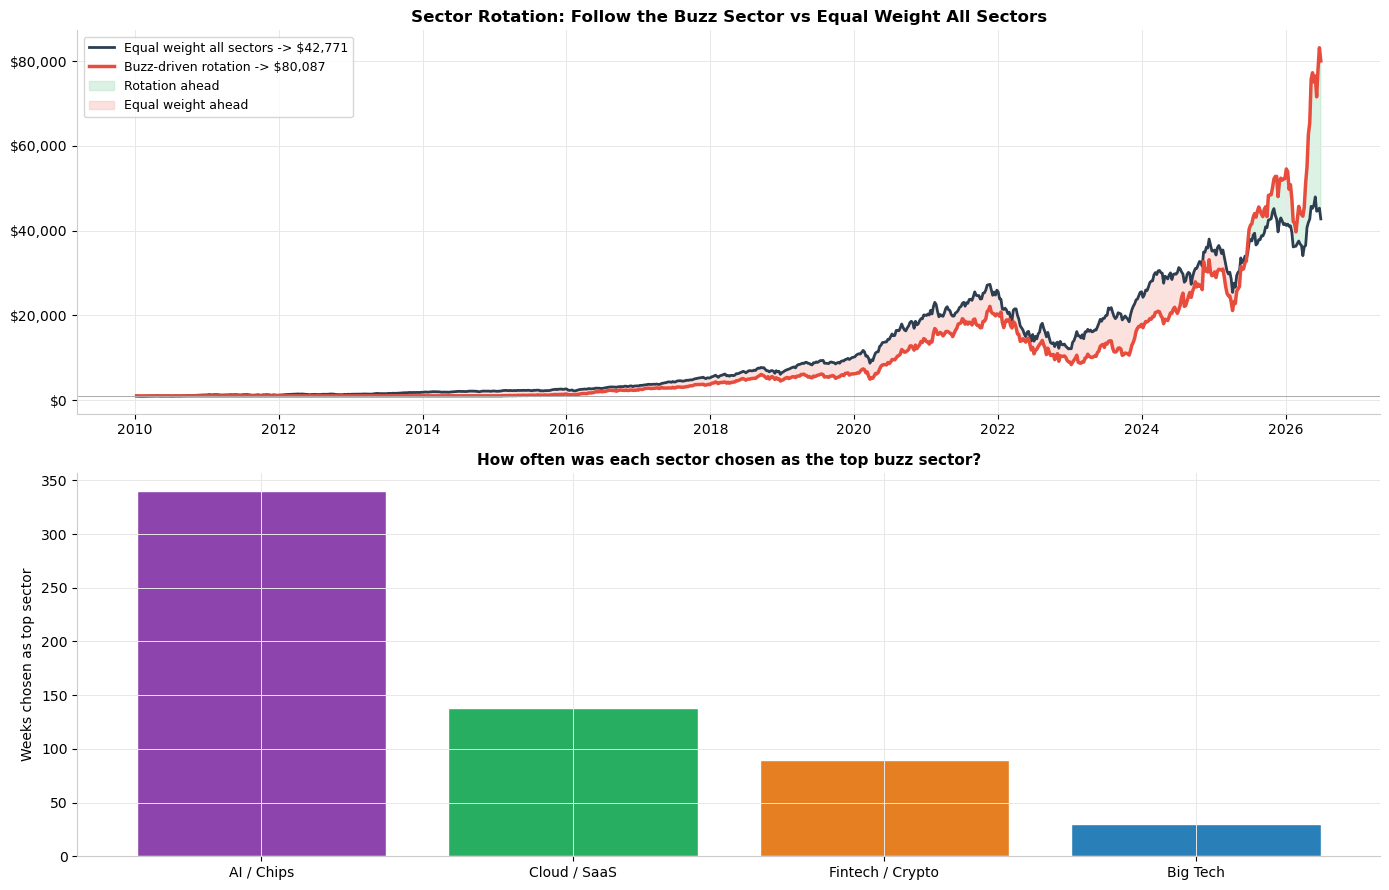


Sector rotation final: $80,087
Equal weight final   : $42,771
Winner: Rotation


In [21]:
SECTORS = {
    'AI / Chips'     : ['NVDA', 'AMD', 'INTC', 'TSM'],
    'Big Tech'       : ['GOOGL', 'MSFT', 'AAPL', 'META', 'AMZN'],
    'Fintech / Crypto': ['COIN', 'PYPL'],
    'Cloud / SaaS'   : ['SNOW', 'DDOG', 'CRM', 'NOW', 'MDB'],
}
SECTOR_COLORS = {
    'AI / Chips'     : '#8e44ad',
    'Big Tech'       : '#2980b9',
    'Fintech / Crypto': '#e67e22',
    'Cloud / SaaS'   : '#27ae60',
    'Cash'           : '#bdc3c7',
}

print('Computing sector sentiment scores ...')

# Weekly average sentiment per sector
sector_sent_rows = []
for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in daily_signals['ticker'].unique()]
    if not available:
        continue
    sub = daily_signals[daily_signals['ticker'].isin(available)].copy()
    sub['date'] = pd.to_datetime(sub['date'])
    weekly = (
        sub.groupby(pd.Grouper(key='date', freq='W'))
        ['norm_sentiment'].mean()
        .reset_index()
    )
    weekly['sector'] = sector
    sector_sent_rows.append(weekly)

df_sector_sent = pd.concat(sector_sent_rows, ignore_index=True)

# For each week, which sector had the best sentiment?
sector_pivot = df_sector_sent.pivot(index='date', columns='sector', values='norm_sentiment')
best_sector_each_week = sector_pivot.idxmax(axis=1)

# Backtest: each week invest in the sector ETF proxy (equal weight of sector stocks)
print('Running sector rotation backtest ...')

# Build weekly returns per sector (equal weight average)
sector_weekly_ret = {}
for sector, tickers_s in SECTORS.items():
    available = [t for t in tickers_s if t in df_prices['ticker'].unique()]
    if not available:
        continue
    sub = df_prices[df_prices['ticker'].isin(available)].copy()
    sub['Date'] = pd.to_datetime(sub['Date'])
    weekly_ret = (
        sub.groupby([pd.Grouper(key='Date', freq='W'), 'ticker'])['daily_return']
        .sum()
        .reset_index()
        .groupby('Date')['daily_return']
        .mean()
    )
    sector_weekly_ret[sector] = weekly_ret

# Simulate rotation
rotation_cash  = POSITION_CASH
holdall_cash   = POSITION_CASH
rotation_hist  = []
holdall_hist   = []
dates_w        = []
allocation_log = []

all_weeks = sorted(set().union(*[s.index for s in sector_weekly_ret.values()]))

# Equal weight buy & hold across all sectors
for week in all_weeks:
    # Buy & hold: average return of all sectors
    all_rets = [sector_weekly_ret[s].get(week, 0) for s in sector_weekly_ret]
    avg_ret  = np.mean([r for r in all_rets if not pd.isna(r)])
    holdall_cash *= (1 + avg_ret)

    # Rotation: use prior week's best sector
    prior_weeks = best_sector_each_week.index[best_sector_each_week.index < week]
    if len(prior_weeks) > 0:
        chosen_sector = best_sector_each_week.loc[prior_weeks[-1]]
        if chosen_sector in sector_weekly_ret and week in sector_weekly_ret[chosen_sector].index:
            sector_ret = sector_weekly_ret[chosen_sector].loc[week]
            if not pd.isna(sector_ret):
                rotation_cash *= (1 + sector_ret)
        allocation_log.append({'week': week, 'sector': chosen_sector})

    rotation_hist.append(rotation_cash)
    holdall_hist.append(holdall_cash)
    dates_w.append(week)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9), facecolor='white')

ax = axes[0]
ax.plot(dates_w, holdall_hist, color='#2c3e50', linewidth=2,
        label=f'Equal weight all sectors -> ${holdall_cash:,.0f}')
ax.plot(dates_w, rotation_hist, color='#e74c3c', linewidth=2.5,
        label=f'Buzz-driven rotation -> ${rotation_cash:,.0f}')
ax.fill_between(dates_w, holdall_hist, rotation_hist,
                where=[r>h for r,h in zip(rotation_hist,holdall_hist)],
                color='#a9dfbf', alpha=0.4, label='Rotation ahead')
ax.fill_between(dates_w, holdall_hist, rotation_hist,
                where=[r<h for r,h in zip(rotation_hist,holdall_hist)],
                color='#f5b7b1', alpha=0.4, label='Equal weight ahead')
ax.axhline(POSITION_CASH, color='#aaaaaa', linewidth=0.7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_facecolor('white')
ax.set_title('Sector Rotation: Follow the Buzz Sector vs Equal Weight All Sectors',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, facecolor='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel 2: which sector was chosen each week
ax = axes[1]
if allocation_log:
    df_alloc = pd.DataFrame(allocation_log)
    df_alloc['week'] = pd.to_datetime(df_alloc['week'])
    sector_counts = df_alloc['sector'].value_counts()
    colors_s = [SECTOR_COLORS.get(s, '#888888') for s in sector_counts.index]
    ax.bar(sector_counts.index, sector_counts.values, color=colors_s, edgecolor='white')
    ax.set_ylabel('Weeks chosen as top sector', fontsize=10)
    ax.set_title('How often was each sector chosen as the top buzz sector?',
                 fontsize=11, fontweight='bold')
    ax.set_facecolor('white')

plt.tight_layout()
plt.show()
print(f'\nSector rotation final: ${rotation_cash:,.0f}')
print(f'Equal weight final   : ${holdall_cash:,.0f}')
winner = 'Rotation' if rotation_cash > holdall_cash else 'Equal weight'
print(f'Winner: {winner}')

---
# Plain English Section
## For anyone who just wants to understand what this data is saying

The charts below don't require any knowledge of finance, tech, or statistics.
The only thing you need to know: **buying a stock low and selling it high makes money.**

The big question: **If the internet was talking positively about a company, did the stock go up soon after?**

In [22]:
from matplotlib.patches import Patch

C_POS   = '#27ae60'
C_NEG   = '#e74c3c'
C_NEU   = '#bdc3c7'
C_PRICE = '#2980b9'
C_BUZZ  = '#8e44ad'
C_HOLD  = '#2c3e50'
C_WIN_B = '#a9dfbf'
C_WIN_H = '#f5b7b1'

top5 = best_per_ticker.head(5)['ticker'].tolist()
print('Top 5 companies where buzz predicted price moves:')
for t in top5:
    row  = best_per_ticker[best_per_ticker['ticker']==t].iloc[0]
    name = COMPANY_MAP.get(t, {}).get('names', [t])[0].title()
    direction = 'went UP' if row['corr'] > 0 else 'went DOWN'
    print(f'  {t:6s} ({name}) - stock {direction} after positive buzz ({row["corr"]:+.2f} using {row["signal"]} at T+{row["horizon"]})')

Top 5 companies where buzz predicted price moves:
  NVO    (Novo Nordisk) - stock went DOWN after positive buzz (-0.28 using sent_momentum at T+3)
  PANW   (Palo Alto Networks) - stock went UP after positive buzz (+0.24 using sent_momentum at T+3)
  PLTR   (Palantir) - stock went UP after positive buzz (+0.23 using sent_momentum at T+1)
  CRWD   (Crowdstrike) - stock went UP after positive buzz (+0.20 using norm_sentiment at T+5)
  PM     (Philip Morris) - stock went UP after positive buzz (+0.16 using norm_sentiment at T+2)


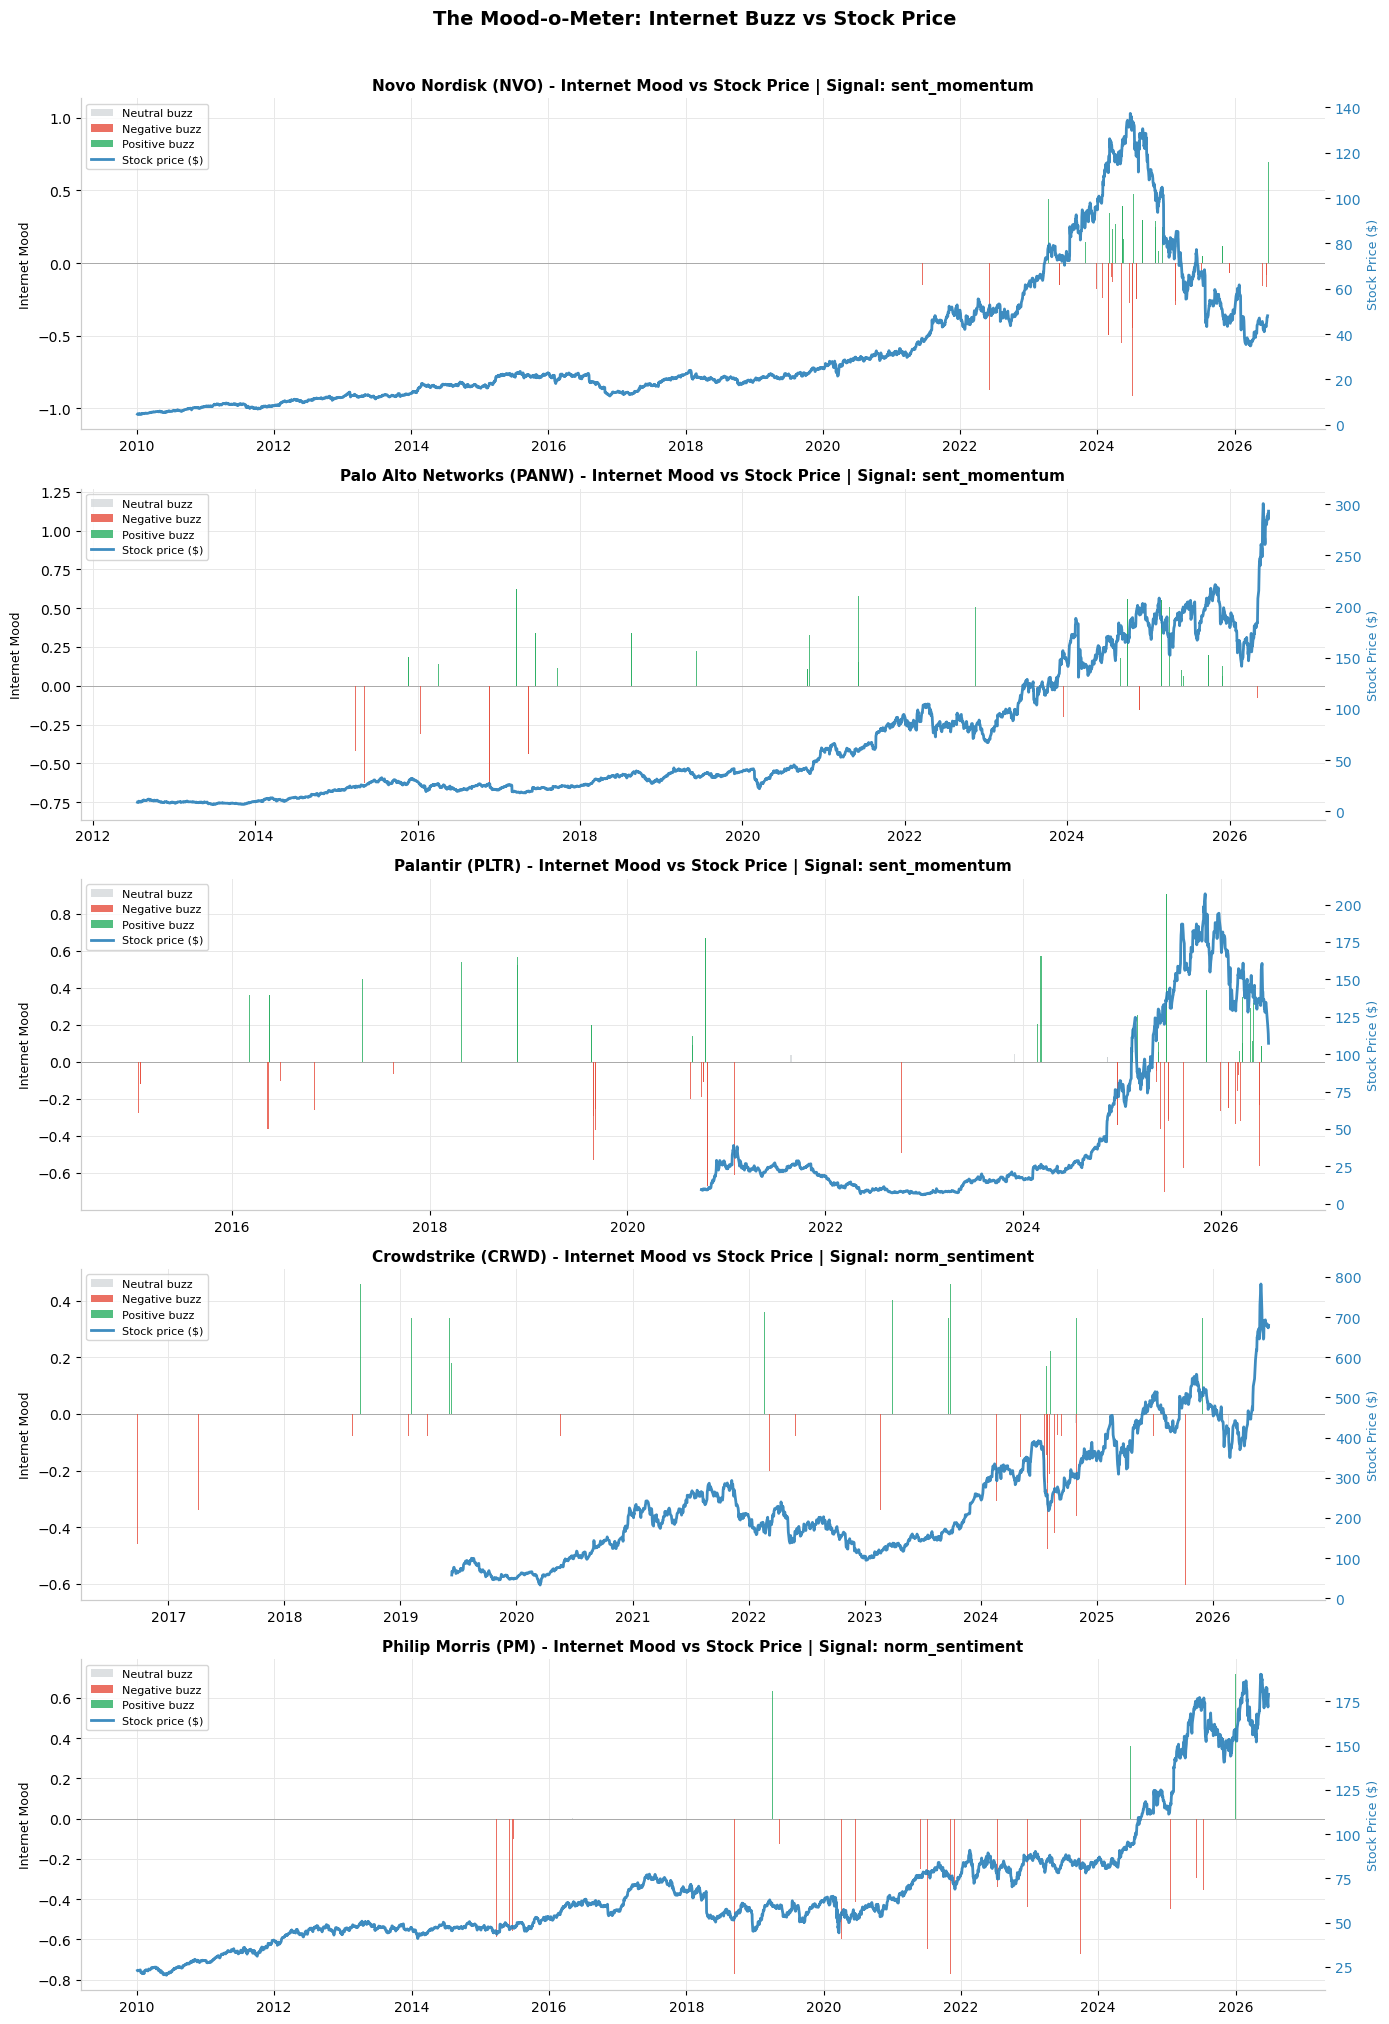

In [23]:
# Mood-o-Meter
best_signal = best_per_ticker.iloc[0]['signal'] if len(best_per_ticker) > 0 else 'sent_roll_3d'

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4*len(top5)), facecolor='white')
if len(top5) == 1: axes = [axes]

for ax, ticker in zip(axes, top5):
    sig   = daily_signals[daily_signals['ticker']==ticker].copy()
    price = df_prices[df_prices['ticker']==ticker].copy()
    sig['date']   = pd.to_datetime(sig['date'])
    price['Date'] = pd.to_datetime(price['Date'])
    name = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()

    sig_col = best_per_ticker[best_per_ticker['ticker']==ticker]['signal'].values
    sig_col = sig_col[0] if len(sig_col) > 0 else 'sent_roll_3d'

    pos = sig[sig[sig_col] >= SENTIMENT_THRESHOLD]
    neg = sig[sig[sig_col] <= -SENTIMENT_THRESHOLD]
    neu = sig[(sig[sig_col] > -SENTIMENT_THRESHOLD) & (sig[sig_col] < SENTIMENT_THRESHOLD)]

    ax.bar(neu['date'], neu[sig_col].fillna(0), color=C_NEU, alpha=0.5, width=2, label='Neutral buzz', zorder=2)
    ax.bar(neg['date'], neg[sig_col].fillna(0), color=C_NEG, alpha=0.8, width=2, label='Negative buzz', zorder=3)
    ax.bar(pos['date'], pos[sig_col].fillna(0), color=C_POS, alpha=0.8, width=2, label='Positive buzz', zorder=3)
    ax.axhline(0, color='#aaaaaa', linewidth=0.7)
    ax.set_ylabel('Internet Mood', fontsize=9)
    ax.set_facecolor('white')

    ax2 = ax.twinx()
    ax2.plot(price['Date'], price['Close'], color=C_PRICE, linewidth=2, alpha=0.9, label='Stock price ($)', zorder=4)
    ax2.set_ylabel('Stock Price ($)', fontsize=9, color=C_PRICE)
    ax2.tick_params(axis='y', labelcolor=C_PRICE)
    ax2.grid(False)
    ax2.set_facecolor('white')

    ax.set_title(f'{name} ({ticker}) - Internet Mood vs Stock Price | Signal: {sig_col}', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8, facecolor='white')

fig.suptitle('The Mood-o-Meter: Internet Buzz vs Stock Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

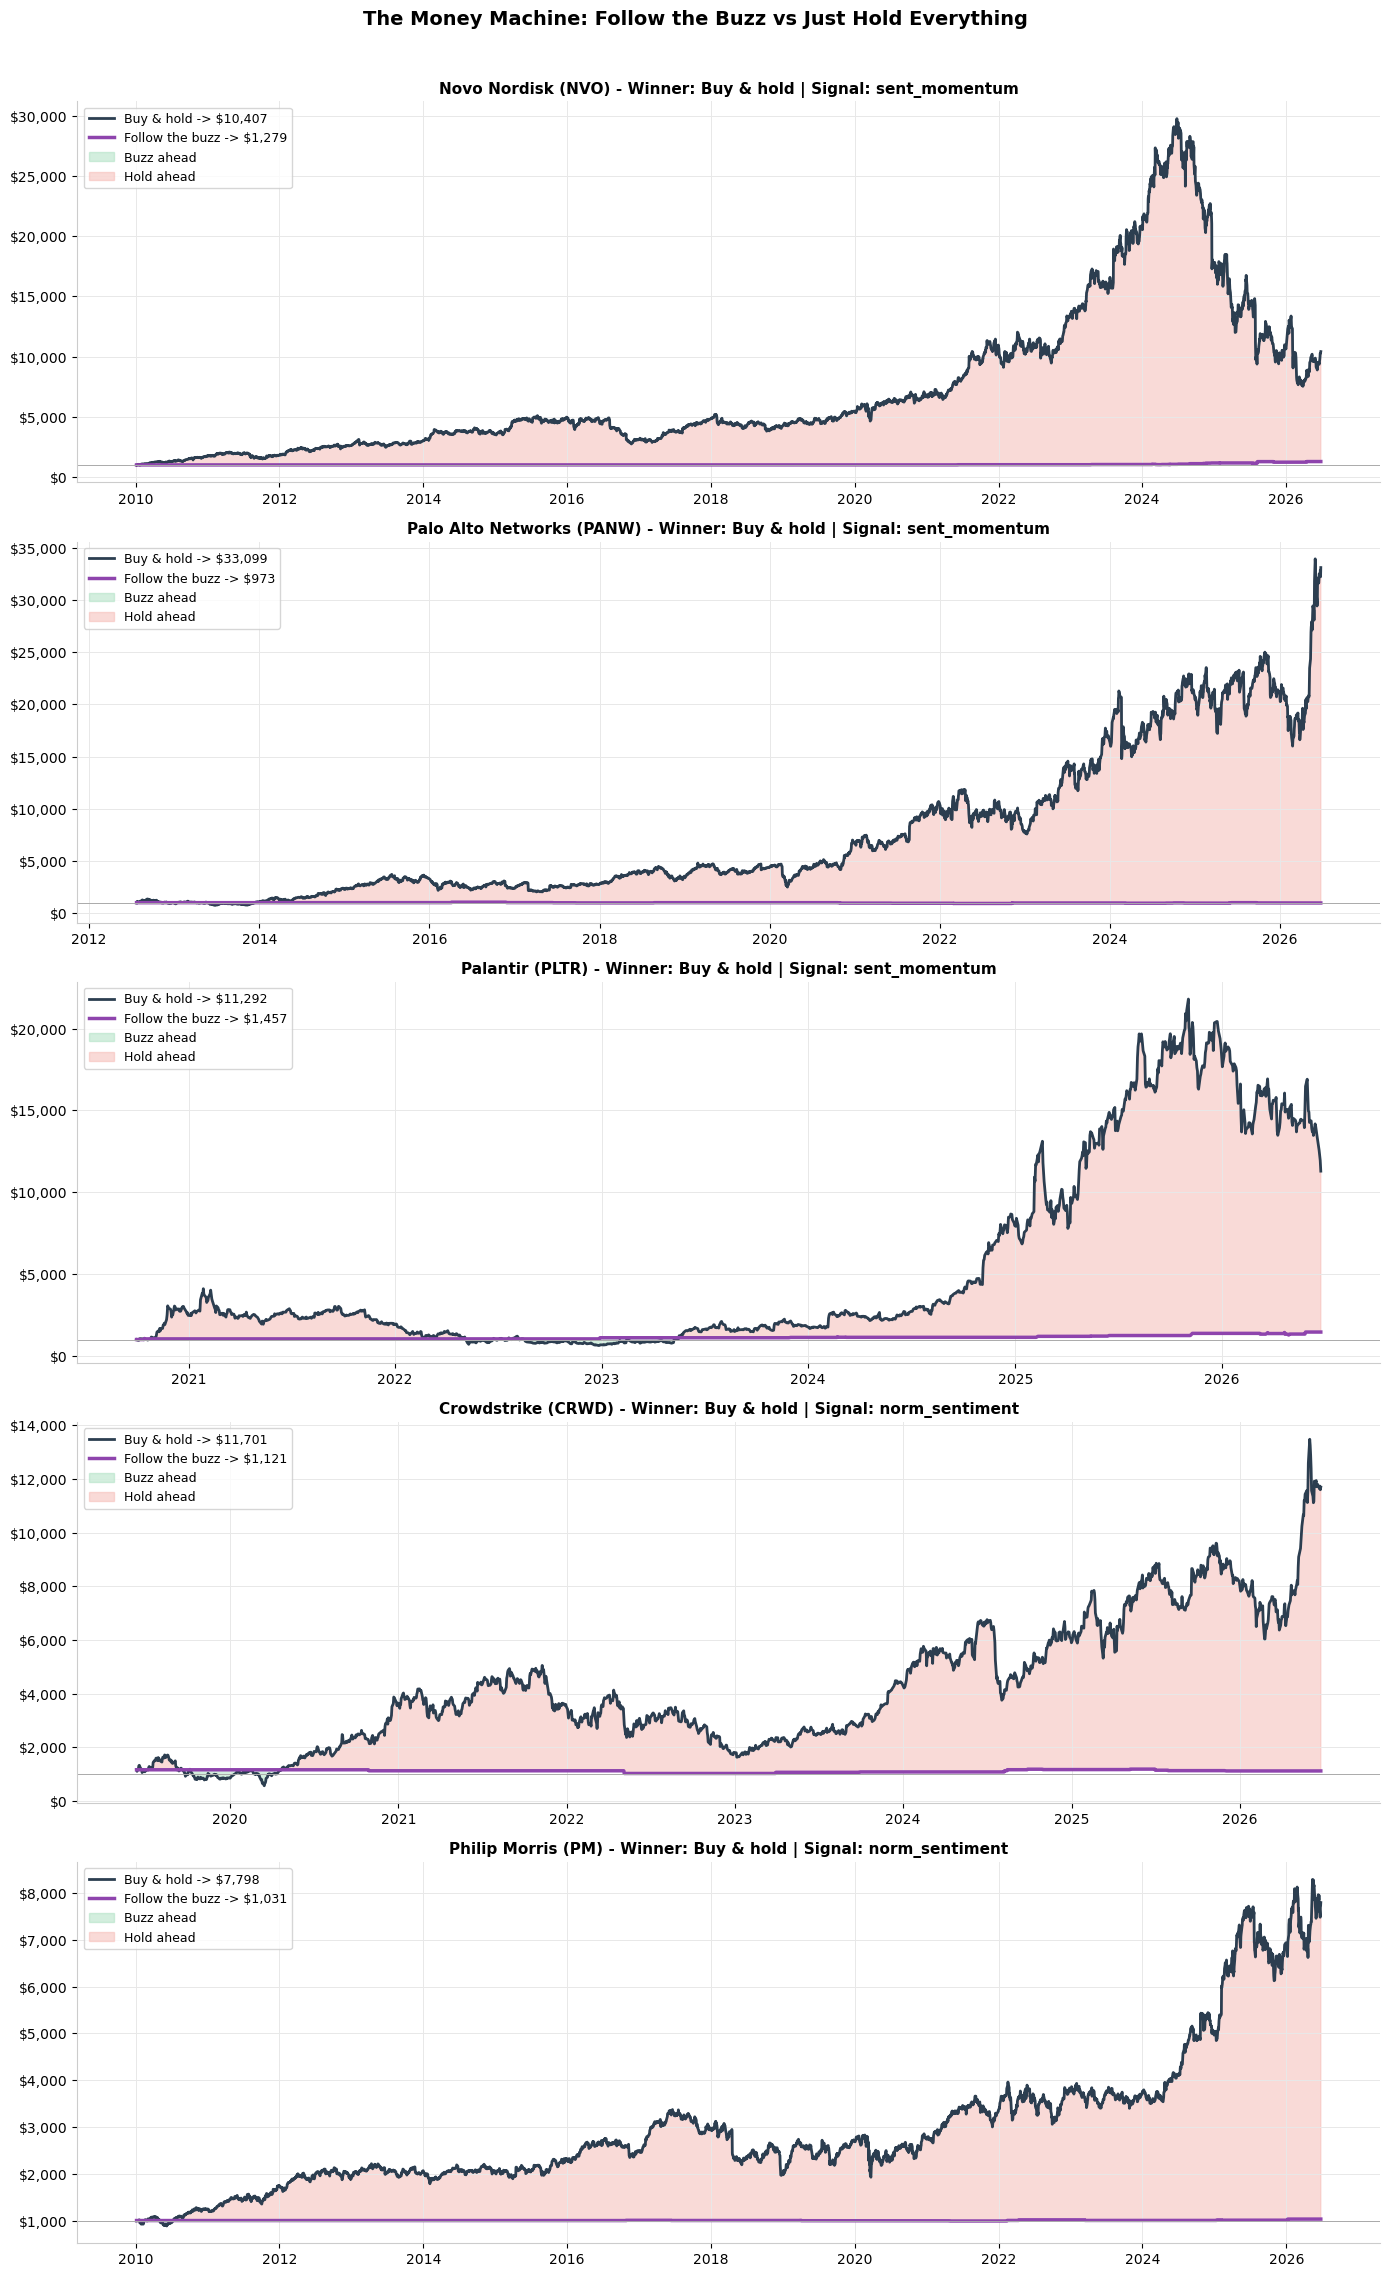

REPORT CARD - Starting with $1,000

  NOVO NORDISK (NVO)
    Buzz strategy: $ 1,279.23  (+27.9%)
    Buy & hold   : $10,406.78  (+940.7%)
    Holding made you $9,127.55 extra

  PALO ALTO NETWORKS (PANW)
    Buzz strategy: $   973.37  (-2.7%)
    Buy & hold   : $33,098.82  (+3209.9%)
    Holding made you $32,125.45 extra

  PALANTIR (PLTR)
    Buzz strategy: $ 1,457.21  (+45.7%)
    Buy & hold   : $11,291.58  (+1029.2%)
    Holding made you $9,834.37 extra

  CROWDSTRIKE (CRWD)
    Buzz strategy: $ 1,121.44  (+12.1%)
    Buy & hold   : $11,700.86  (+1070.1%)
    Holding made you $10,579.42 extra

  PHILIP MORRIS (PM)
    Buzz strategy: $ 1,031.27  (+3.1%)
    Buy & hold   : $ 7,798.32  (+679.8%)
    Holding made you $6,767.05 extra

Buzz strategy won in 0/5 companies
Note: past performance does not guarantee future results!


In [24]:
# Money Machine
INVESTMENT_START_DATE = None   # change to e.g. '2018-01-01' to try different start
STARTING_CASH = 1000

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4.5*len(top5)), facecolor='white')
if len(top5) == 1: axes = [axes]

strategy_summary = []

for ax, ticker in zip(axes, top5):
    row     = best_per_ticker[best_per_ticker['ticker']==ticker].iloc[0]
    sig_col = row['signal']
    sig     = daily_signals[daily_signals['ticker']==ticker].copy()
    price   = df_prices[df_prices['ticker']==ticker].copy()
    sig['date']   = pd.to_datetime(sig['date'])
    price         = price.set_index('Date').sort_index()
    name = COMPANY_MAP.get(ticker, {}).get('names', [ticker])[0].title()

    if INVESTMENT_START_DATE:
        start = pd.Timestamp(INVESTMENT_START_DATE)
        price = price[price.index >= start]
        sig   = sig[sig['date'] >= start]

    buzz_w = STARTING_CASH
    hold_w = STARTING_CASH
    buzz_h, hold_h, dates_u = [], [], []
    sent_idx = sig.set_index('date').sort_index()

    for date in price.index:
        ret = price.loc[date, 'daily_return']
        if pd.isna(ret): continue
        hold_w *= (1 + ret)
        yesterday   = date - pd.Timedelta(days=1)
        prior_dates = sent_idx.index[sent_idx.index <= yesterday]
        if len(prior_dates) > 0:
            prior_sent = sent_idx.loc[prior_dates[-1], sig_col]
            if not pd.isna(prior_sent) and prior_sent >= SENTIMENT_THRESHOLD:
                buzz_w *= (1 + ret)
        buzz_h.append(buzz_w)
        hold_h.append(hold_w)
        dates_u.append(date)

    strategy_summary.append({
        'ticker': ticker, 'name': name,
        'buzz_final': round(buzz_w, 2), 'holdall_final': round(hold_w, 2),
        'buzz_wins': buzz_w > hold_w,
    })

    ax.plot(dates_u, hold_h, color=C_HOLD, linewidth=2, label=f'Buy & hold -> ${hold_w:,.0f}')
    ax.plot(dates_u, buzz_h, color=C_BUZZ, linewidth=2.5, label=f'Follow the buzz -> ${buzz_w:,.0f}')
    ax.fill_between(dates_u, hold_h, buzz_h,
                    where=[b>h for b,h in zip(buzz_h,hold_h)], color=C_WIN_B, alpha=0.5, label='Buzz ahead')
    ax.fill_between(dates_u, hold_h, buzz_h,
                    where=[b<h for b,h in zip(buzz_h,hold_h)], color=C_WIN_H, alpha=0.5, label='Hold ahead')
    ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_facecolor('white')
    winner = 'Buzz' if buzz_w > hold_w else 'Buy & hold'
    ax.set_title(f'{name} ({ticker}) - Winner: {winner} | Signal: {sig_col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left', facecolor='white')

fig.suptitle('The Money Machine: Follow the Buzz vs Just Hold Everything', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df_summary = pd.DataFrame(strategy_summary)
print('=' * 65)
print(f'REPORT CARD - Starting with ${STARTING_CASH:,}')
print('=' * 65)
for _, row in df_summary.iterrows():
    diff = row['buzz_final'] - row['holdall_final']
    buzz_ret  = (row['buzz_final']    / STARTING_CASH - 1) * 100
    hold_ret  = (row['holdall_final'] / STARTING_CASH - 1) * 100
    print(f"\n  {row['name'].upper()} ({row['ticker']})")
    print(f"    Buzz strategy: ${row['buzz_final']:>9,.2f}  ({buzz_ret:+.1f}%)")
    print(f"    Buy & hold   : ${row['holdall_final']:>9,.2f}  ({hold_ret:+.1f}%)")
    print(f"    {'Buzz made you' if diff > 0 else 'Holding made you'} ${abs(diff):,.2f} extra")
winners = df_summary['buzz_wins'].sum()
print(f'\nBuzz strategy won in {winners}/{len(df_summary)} companies')
print('Note: past performance does not guarantee future results!')